# Perch V2 — Zero-Shot vs Trained Classifier Evaluation

### Data format expected
- **WAV folder**: flat folder of `.wav` files named like `SCW1807_20200711_082500.wav`
- **Annotation JSON**: single JSON file mapping `SCW1807_20200711_082500-contours.json` → list of `{start, end, label}` dicts

### What this notebook does

1. Extracts **fixed 5s windows** and associates the corresponding labels
2. Embeds all windows with **Perch V2**
3. Evaluates **zero-shot** performance using Perch V2's built-in logits
4. Trains a **linear classifier** on top of the embeddings
5. Reports **per-class precision / recall / F1** for both, with plots
6. Performs **Dimensinality Reduction** to asses class separation in 2D and cluster formation.


> **Requirements**: GPU runtime + perch-hoplite installed (cells below)

In order to use Perch V2, you must install this version (or later) of TensorFlow and cuda

In [ ]:
%pip install tensorflow[and-cuda]~=2.20.0rc0

Choose the working gpu

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import tensorflow as tf
import torch

print(f"TF GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"PyTorch: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Only use GPU 0
    tf.config.set_visible_devices(gpus[0], 'GPU')
    # Optional: prevent TF from grabbing all memory
    tf.config.experimental.set_memory_growth(gpus[0], True)
print(f"TF using: {tf.config.get_visible_devices('GPU')}")

2026-05-05 11:46:32.181445: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 11:46:32.232577: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 11:46:33.619269: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch: NVIDIA L4
TF using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#@title Imports
import json
import warnings
from pathlib import Path
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report
)
import librosa.display
import soxr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from perch_hoplite.zoo import model_configs

In [3]:
#@title Configuration { vertical-output: true }


#@markdown Folder for base saving
save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES'

#@markdown Window size in seconds fed to Perch V2 (default 5.0)
window_size_s = 5.0  #@param {type:'number'}

#@markdown Minimum overlap (s) between an annotation and a window to label it as positive
min_overlap_s = 0.001  #@param {type:'number'}

#@markdown Fraction of data held out for testing
test_size = 0.3  #@param {type:'number'}

#@markdown Random seed
random_seed = 123  #@param {type:'number'}

In [6]:
#@title Load Perch V2 model
model_key = 'perch_v2'
embedding_model = model_configs.load_model_by_name(model_key)
sr = embedding_model.sample_rate

perch_class_names = list(embedding_model.class_list['labels'].classes)
print(f'Model loaded. Sample rate: {sr} Hz')
print(f'Perch V2 built-in classes: {len(perch_class_names)}')

I0000 00:00:1777974409.386678  825863 gpu_device.cc:2020] Created device /device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9
I0000 00:00:1777974409.775567  825863 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


Model loaded. Sample rate: 32000 Hz
Perch V2 built-in classes: 14795


In [8]:
#@title Parse annotations and build window list (Cetacean multi-species)

from pathlib import Path
from collections import defaultdict
import re

dataset_root = Path('/data2/mromaniuc/cet-det/datasets/ALNITAK_CAVANILLES')  #@param {type:'string'}

def latin_to_short(latin):
    parts = latin.strip().split()
    if len(parts) < 2:
        return (parts[0][:6].lower() if parts else 'unk')
    return parts[0][:3].lower() + parts[1][:3].capitalize()


def parse_species_field(field):
    if not field or (isinstance(field, float) and pd.isna(field)):
        return []
    return [latin_to_short(s) for s in str(field).split('|') if s.strip()]


def extract_deployment_id(wav_path):
    """Extract deployment folder name from wav path, e.g. 'deployment-1_100'"""
    for part in Path(wav_path).parts:
        if part.startswith('deployment-'):
            return part
    return 'unknown'


# -------- 1. Load all annotations and index all WAVs --------
events_by_begin_file = defaultdict(list)
wav_index = {}

species_folders = sorted(p for p in dataset_root.iterdir() if p.is_dir())
print(f'Found {len(species_folders)} species folders')

for species_dir in species_folders:
    ann_dir = species_dir / '1-annotation-tables'
    wav_dir = species_dir / '3-complete-WAV'

    if not ann_dir.is_dir() or not wav_dir.is_dir():
        print(f'  SKIP {species_dir.name}: ann={ann_dir.is_dir()}, wav={wav_dir.is_dir()}')
        continue

    n_wav_before = len(wav_index)
    for wav_path in list(wav_dir.rglob('*.WAV')) + list(wav_dir.rglob('*.wav')):
        wav_index[wav_path.name] = wav_path

    n_ev_before = sum(len(v) for v in events_by_begin_file.values())
    for ann_file in ann_dir.glob('*.txt'):
        try:
            df = pd.read_csv(ann_file, sep='\t')
        except Exception as e:
            print(f'    could not read {ann_file.name}: {e}')
            continue

        required = {'Begin File', 'End File', 'Begin Time (s)', 'End Time (s)',
                    'signalType', 'species', 'deploymentID'}
        if required - set(df.columns):
            print(f'    {ann_file.name}: missing columns {required - set(df.columns)}')
            continue

        for _, row in df.iterrows():
            species_codes = parse_species_field(row['species'])
            sig = str(row['signalType']).strip().lower() if pd.notna(row['signalType']) else ''
            if not species_codes or not sig:
                continue
            events_by_begin_file[row['Begin File']].append({
                'begin_file': row['Begin File'],
                'end_file': row['End File'],
                'begin_time': float(row['Begin Time (s)']),
                'end_time': float(row['End Time (s)']),
                'species_codes': species_codes,
                'signal_type': sig,
                'deployment_id': row['deploymentID'],
                'source_species_folder': species_dir.name,
            })

    print(f'  {species_dir.name}: +{len(wav_index) - n_wav_before} WAVs, '
          f'+{sum(len(v) for v in events_by_begin_file.values()) - n_ev_before} events')

print(f'\nTotal: {len(wav_index)} WAV files, '
      f'{sum(len(v) for v in events_by_begin_file.values())} annotation events')


# -------- 2. Slice cross-file events into per-WAV intervals --------
needed = set(events_by_begin_file.keys())
for evs in events_by_begin_file.values():
    for e in evs:
        needed.add(e['end_file'])

wav_duration = {}
for name in needed:
    if name in wav_index:
        try:
            wav_duration[name] = librosa.get_duration(path=str(wav_index[name]))
        except Exception as ex:
            print(f'  duration failed for {name}: {ex}')

events_per_wav = defaultdict(list)
for begin_file, evs in events_by_begin_file.items():
    if begin_file not in wav_index:
        continue
    dur_begin = wav_duration.get(begin_file)
    if dur_begin is None:
        continue
    for e in evs:
        if e['begin_file'] == e['end_file']:
            ls, le = max(0.0, e['begin_time']), min(dur_begin, e['end_time'])
            if le > ls:
                events_per_wav[begin_file].append(
                    (ls, le, e['species_codes'], e['signal_type'], e['deployment_id']))
        else:
            ls = max(0.0, e['begin_time'])
            if dur_begin > ls:
                events_per_wav[begin_file].append(
                    (ls, dur_begin, e['species_codes'], e['signal_type'], e['deployment_id']))
            carry = e['end_time'] - dur_begin
            if carry > 0 and e['end_file'] in wav_index:
                dur_end = wav_duration.get(e['end_file'])
                if dur_end is not None:
                    events_per_wav[e['end_file']].append(
                        (0.0, min(carry, dur_end), e['species_codes'], e['signal_type'], e['deployment_id']))

# -------- 3. Build 5 s windows over ALL indexed WAVs --------
windows = []

for wav_name, wav_path in wav_index.items():
    dur = wav_duration.get(wav_name)
    if dur is None:
        try:
            dur = librosa.get_duration(path=str(wav_path))
            wav_duration[wav_name] = dur
        except Exception as ex:
            print(f'  duration failed for {wav_name}: {ex}')
            continue

    intervals = events_per_wav.get(wav_name, [])

    # deployment folder from path (e.g. 'deployment-1_100')
    deployment_folder = extract_deployment_id(wav_path)
    # deployment_id from annotation if available, else fall back to folder name
    deployment_id = intervals[0][4] if intervals else deployment_folder

    for i in range(int(dur // window_size_s)):
        ws, we = i * window_size_s, (i + 1) * window_size_s
        tags = set()
        species_hits, signal_hits = defaultdict(int), defaultdict(int)

        for (ls, le, species_codes, sig, _dep) in intervals:
            if min(we, le) - max(ws, ls) >= min_overlap_s:
                for sp in species_codes:
                    tags.add(f'{sp}_{sig}')
                    species_hits[sp] += 1
                signal_hits[sig] += 1

        windows.append({
            'wav_path':          str(wav_path),
            'wav_name':          wav_name,
            'offset_s':          ws,
            'label':             '+'.join(sorted(tags)) if tags else 'background',
            'deployment_folder': deployment_folder,   # 'deployment-1_100' — join key for the Excel
            'deployment_id':     deployment_id,       # from annotation table
            'species_folder':    wav_path.parents[2].name,
            'n_species':         len(species_hits),
            'species_set':       '|'.join(sorted(species_hits.keys())) if species_hits else '',
            'signal_set':        '|'.join(sorted(signal_hits.keys())) if signal_hits else '',
        })

windows_df = pd.DataFrame(windows, columns=[
    'wav_path', 'wav_name', 'offset_s', 'label',
    'deployment_folder', 'deployment_id',
    'species_folder', 'n_species', 'species_set', 'signal_set'])

print(f'\nTotal windows: {len(windows_df)}')

if len(windows_df):
    print('\n=== Top 25 compound labels ===')
    print(windows_df['label'].value_counts().head(25).to_string())

    print('\n=== Per species folder ===')
    print(windows_df.groupby('species_folder').size().to_string())

    print('\n=== Deployments found ===')
    print(windows_df.groupby('deployment_folder').size().to_string())

    print('\n=== Signal-type presence ===')
    for sig in ['clicks', 'whistles', 'buzz', 'burst_pulses', 'moans', 'calls']:
        n = windows_df['signal_set'].str.contains(rf'(?:^|\|){re.escape(sig)}(?:\||$)', regex=True).sum()
        if n:
            print(f'  {sig:14s}: {n}')

    print('\n=== Species-count breakdown ===')
    print(f'  multi-species:  {(windows_df["n_species"] > 1).sum()}')
    print(f'  single-species: {(windows_df["n_species"] == 1).sum()}')
    print(f'  background:     {(windows_df["n_species"] == 0).sum()}')

Found 6 species folders
  Delphinidae: +238 WAVs, +464 events
  Globicephala_melas: +72 WAVs, +184 events
  Grampus_griseus: +21 WAVs, +10 events
  Physeter_macrocephalus: +74 WAVs, +10 events
  Stenella_coeruleoalba: +9 WAVs, +8 events
  Tursiops_truncatus: +38 WAVs, +102 events

Total: 452 WAV files, 778 annotation events

Total windows: 5202

=== Top 25 compound labels ===
label
background                                                     4348
delphi_clicks                                                   304
phyMac_clicks                                                   179
gloMel_clicks+turTru_clicks                                     106
gloMel_clicks                                                    89
turTru_clicks                                                    58
graGri_clicks                                                    45
gloMel_whistles                                                  32
gloMel_clicks+gloMel_whistles                                    20
ste

just to check wether we correctly assigned the labels:

In [9]:
#@title Visualize window labels grouped by deployment

from matplotlib.patches import Patch
from matplotlib import colormaps
import os

#@markdown Limit to a single species folder (empty = all). Useful for exploring.
filter_species_folder = ''  #@param {type:'string'}

#@markdown Max deployments to draw (avoids gigantic figures). 0 = no limit.
max_deployments = 40  #@param {type:'integer'}

# -------- 1. Build per-deployment data from events_per_wav + wav_index --------
# Each deployment = one subfolder under 3-complete-WAV (e.g. 'deployment-B_D06').
# Within a deployment, WAVs are contiguous chronological recordings, so we
# lay them end-to-end on a single timeline.

def deployment_of(wav_path):
    # wav_path.parent = 'deployment-X_DYY', parents[1] = '3-complete-WAV', parents[2] = species folder
    return wav_path.parent.name

# Group WAVs by (species_folder, deployment)
deployments = defaultdict(list)  # (species_folder, deployment_name) -> [(wav_name, wav_path, duration)]
for wav_name, wav_path in wav_index.items():
    sp = wav_path.parents[2].name
    if filter_species_folder and sp != filter_species_folder:
        continue
    dur = wav_duration.get(wav_name)
    if dur is None:
        continue
    deployments[(sp, deployment_of(wav_path))].append((wav_name, wav_path, dur))

# Sort WAVs within each deployment by filename (they encode timestamps, so this orders them chronologically)
for key in deployments:
    deployments[key].sort(key=lambda x: x[0])

deployment_keys = sorted(deployments.keys())
if max_deployments and len(deployment_keys) > max_deployments:
    print(f'Limiting to first {max_deployments} of {len(deployment_keys)} deployments')
    deployment_keys = deployment_keys[:max_deployments]

# -------- 2. Pick a stable color per species code --------
all_species_codes = set()
for s in windows_df['species_set']:
    if s:
        all_species_codes.update(s.split('|'))
all_species_codes = sorted(all_species_codes)

cmap = colormaps['tab10']
species_color = {sp: cmap(i % 10) for i, sp in enumerate(all_species_codes)}
species_color['background'] = '#e5e5e5'
species_color['mixed'] = '#8e44ad'

def window_color(row):
    if row['n_species'] == 0:
        return species_color['background']
    if row['n_species'] > 1:
        return species_color['mixed']
    return species_color[row['species_set']]

signal_hatch = {'clicks': '', 'whistles': '///'}

# -------- 3. Plot --------
n = len(deployment_keys)
fig, axes = plt.subplots(n, 1, figsize=(16, 1.8 * n))
if n == 1:
    axes = [axes]

# Fast lookup into windows_df by wav_path
windows_by_wav = dict(list(windows_df.groupby('wav_path')))

for ax, (species_folder, dep_name) in zip(axes, deployment_keys):
    wavs = deployments[(species_folder, dep_name)]
    cursor = 0.0              # running offset on the concatenated deployment timeline
    file_boundaries = [0.0]

    for wav_name, wav_path, dur in wavs:
        file_wins = windows_by_wav.get(str(wav_path))
        if file_wins is not None:
            for _, row in file_wins.iterrows():
                c = window_color(row)
                ax.barh(0, window_size_s, left=cursor + row['offset_s'],
                        height=0.55, color=c, edgecolor='white', linewidth=0.2)

        # Raw annotations: draw from the sliced intervals (already in local WAV time)
        for (ls, le, species_codes, sig, _dep) in events_per_wav.get(wav_name, []):
            # One bar per species in the annotation, stacked slightly
            for j, sp in enumerate(species_codes):
                c = species_color.get(sp, '#555555')
                ax.barh(0.75 + 0.12 * j, le - ls, left=cursor + ls,
                        height=0.1, color=c, alpha=0.85,
                        hatch=signal_hatch.get(sig, ''))

        cursor += dur
        file_boundaries.append(cursor)

    # File boundary ticks
    for b in file_boundaries[1:-1]:
        ax.axvline(b, color='black', linewidth=0.3, alpha=0.3, ymin=0, ymax=0.55 / 1.2)

    total_wins = sum(len(windows_by_wav.get(str(wp), [])) for _, wp, _ in wavs)
    ax.set_xlim(0, cursor)
    ax.set_ylim(-0.4, 1.2)
    ax.set_yticks([0, 0.85])
    ax.set_yticklabels(['windows', 'annotations'], fontsize=6)
    ax.set_title(f'{species_folder} / {dep_name}  —  {len(wavs)} WAVs, '
                 f'{cursor/60:.1f} min, {total_wins} windows', fontsize=8)
    ax.tick_params(axis='x', labelsize=6)
    ax.set_xlabel('Time in deployment (s)', fontsize=6)

# Legend
legend_elements = [Patch(facecolor=species_color[sp], label=sp) for sp in all_species_codes]
legend_elements += [
    Patch(facecolor=species_color['background'], label='background'),
    Patch(facecolor=species_color['mixed'], label='multi-species window'),
]
legend_elements += [
    Patch(facecolor='white', edgecolor='black', label='raw clicks'),
    Patch(facecolor='white', edgecolor='black', hatch='///', label='raw whistles'),
]

axes[0].legend(handles=legend_elements, loc='upper right',
               fontsize=6, ncol=min(len(legend_elements), 6),
               bbox_to_anchor=(1.0, 1.8))

plt.suptitle(
    f'Cetacean dataset — {len(deployment_keys)} deployments, '
    f'{len(windows_df)} total windows '
    f'({(windows_df["n_species"] > 0).sum()} positive, '
    f'{(windows_df["n_species"] == 0).sum()} background)',
    fontsize=11, y=1.002
)
plt.tight_layout()

os.makedirs(f'{save_dir}/figures', exist_ok=True)
out_path = f'{save_dir}/figures/visualize_windows.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.close()
print(f'Saved to {out_path} — {len(deployment_keys)} deployments')

Saved to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/figures/visualize_windows.png — 29 deployments


In [11]:
import soxr
from tqdm import tqdm

assert sr == 32000, f'Expected Perch sample rate 32000, got {sr}'

windows_df = windows_df.reset_index(drop=True)
target_len = int(window_size_s * sr)

embeddings_list, logits_list, labels_list, kept_idx, failed_idx = [], [], [], [], []

ckpt_every = 500
ckpt_dir = Path(save_dir) / 'embeddings_ckpt'
ckpt_dir.mkdir(parents=True, exist_ok=True)

for i, row in tqdm(windows_df.iterrows(), total=len(windows_df), desc='embedding'):
    try:
        audio_native, native_sr = librosa.load(
            row['wav_path'], sr=None,
            offset=row['offset_s'], duration=window_size_s, mono=True
        )
        if native_sr != sr:
            audio = soxr.resample(audio_native, native_sr, sr)
        else:
            audio = audio_native

        if len(audio) < target_len:
            audio = np.pad(audio, (0, target_len - len(audio)))
        audio = audio[:target_len].astype(np.float32)

        out = embedding_model.embed(audio)
        embeddings_list.append(out.embeddings[0].mean(axis=0))
        logits_list.append(out.logits['label'][0])
        labels_list.append(row['label'])
        kept_idx.append(i)

    except Exception as e:
        failed_idx.append(i)
        tqdm.write(f'  FAILED [{i}] {Path(row["wav_path"]).name} @ {row["offset_s"]:.1f}s — {repr(e)}')

    if (i + 1) % ckpt_every == 0 and embeddings_list:
        np.savez(ckpt_dir / f'ckpt_{i+1:06d}.npz',
                 X=np.stack(embeddings_list),
                 Z=np.stack(logits_list),
                 y=np.array(labels_list),
                 kept_idx=np.array(kept_idx))

X = np.stack(embeddings_list)
Z = np.stack(logits_list)
y = np.array(labels_list)
kept_idx = np.array(kept_idx)
meta_df = windows_df.loc[kept_idx].reset_index(drop=True)

print(f'\nDone. {len(X)} embedded, {len(failed_idx)} failed.')
print(f'Embedding shape: {X.shape}  |  Logits shape: {Z.shape}')
print(f'Deployments in embedded set: {meta_df["deployment_folder"].nunique()}')

np.savez(Path(save_dir) / 'embeddings_final.npz',
         X=X, Z=Z, y=y, kept_idx=kept_idx)
meta_df.to_parquet(Path(save_dir) / 'embeddings_meta.parquet', index=False)

print(f'Saved embeddings to {save_dir}/embeddings_final.npz')
print(f'Saved metadata   to {save_dir}/embeddings_meta.parquet')

embedding: 100%|██████████| 5202/5202 [02:15<00:00, 38.32it/s]



Done. 5202 embedded, 0 failed.
Embedding shape: (5202, 1536)  |  Logits shape: (5202, 14795)
Deployments in embedded set: 27
Saved embeddings to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/embeddings_final.npz
Saved metadata   to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/embeddings_meta.parquet


In [13]:
os.makedirs(f'{save_dir}/embeddings', exist_ok=True)

# --- Align metadata with embedded windows ---
metadata_df = windows_df.loc[kept_idx].reset_index(drop=True)
metadata_df['embedding_idx'] = metadata_df.index

# --- NaN diagnostic ---
nan_in_X = np.isnan(X).any(axis=1)
nan_in_Z = np.isnan(Z).any(axis=1)
nan_any   = nan_in_X | nan_in_Z

print('=== NaN DIAGNOSTIC ===')
print(f'Total windows:           {len(X)}')
print(f'Rows with NaN in X:      {nan_in_X.sum()}')
print(f'Rows with NaN in Z:      {nan_in_Z.sum()}')
print(f'Rows with NaN in either: {nan_any.sum()}')

if nan_any.sum() > 0:
    for idx in np.where(nan_any)[0]:
        row = metadata_df.iloc[idx]
        print(f'  row {idx:5d} | {y[idx]:10s} | {Path(row.wav_path).name} '
              f'@ {row.offset_s:.1f}s | NaN in X: {np.isnan(X[idx]).sum()}, '
              f'NaN in Z: {np.isnan(Z[idx]).sum()}')

    pct = nan_any.sum() / len(X) * 100
    if pct < 5.0:
        print(f'\n{nan_any.sum()} NaN rows ({pct:.2f}%) — dropping, proceeding.')
        valid       = ~nan_any
        X_save      = X[valid]
        Z_save      = Z[valid]
        y_save      = y[valid]
        metadata_df = metadata_df[valid].reset_index(drop=True)
        metadata_df['embedding_idx'] = metadata_df.index
    else:
        print(f'\nWARNING: {pct:.2f}% NaN — too many to drop, investigate first. Saving as-is.')
        X_save, Z_save, y_save = X, Z, y
else:
    print('\nNo NaN values — data is clean.')
    X_save, Z_save, y_save = X, Z, y

np.save(f'{save_dir}/embeddings/X_embeddings.npy', X_save)
np.save(f'{save_dir}/embeddings/Z_logits.npy',     Z_save)
np.save(f'{save_dir}/embeddings/y_labels.npy',     y_save)
metadata_df.to_csv(f'{save_dir}/embeddings/metadata.csv', index=False)

print(f'\n=== SAVED TO {save_dir}/embeddings ===')
print(f'  X_embeddings.npy  — {X_save.shape}')
print(f'  Z_logits.npy      — {Z_save.shape}')
print(f'  y_labels.npy      — {y_save.shape}')
print(f'  metadata.csv      — {len(metadata_df)} rows')
print(f'  deployments       — {metadata_df["deployment_folder"].nunique()}')
print(f'\nClass distribution:')
print(pd.Series(y_save).value_counts())

=== NaN DIAGNOSTIC ===
Total windows:           5202
Rows with NaN in X:      0
Rows with NaN in Z:      0
Rows with NaN in either: 0

No NaN values — data is clean.

=== SAVED TO /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/embeddings ===
  X_embeddings.npy  — (5202, 1536)
  Z_logits.npy      — (5202, 14795)
  y_labels.npy      — (5202,)
  metadata.csv      — 5202 rows
  deployments       — 27

Class distribution:
background                                                     4348
delphi_clicks                                                   304
phyMac_clicks                                                   179
gloMel_clicks+turTru_clicks                                     106
gloMel_clicks                                                    89
turTru_clicks                                                    58
graGri_clicks                                                    45
gloMel_whistles                                                  32
gloMel_clicks+gloMel_w

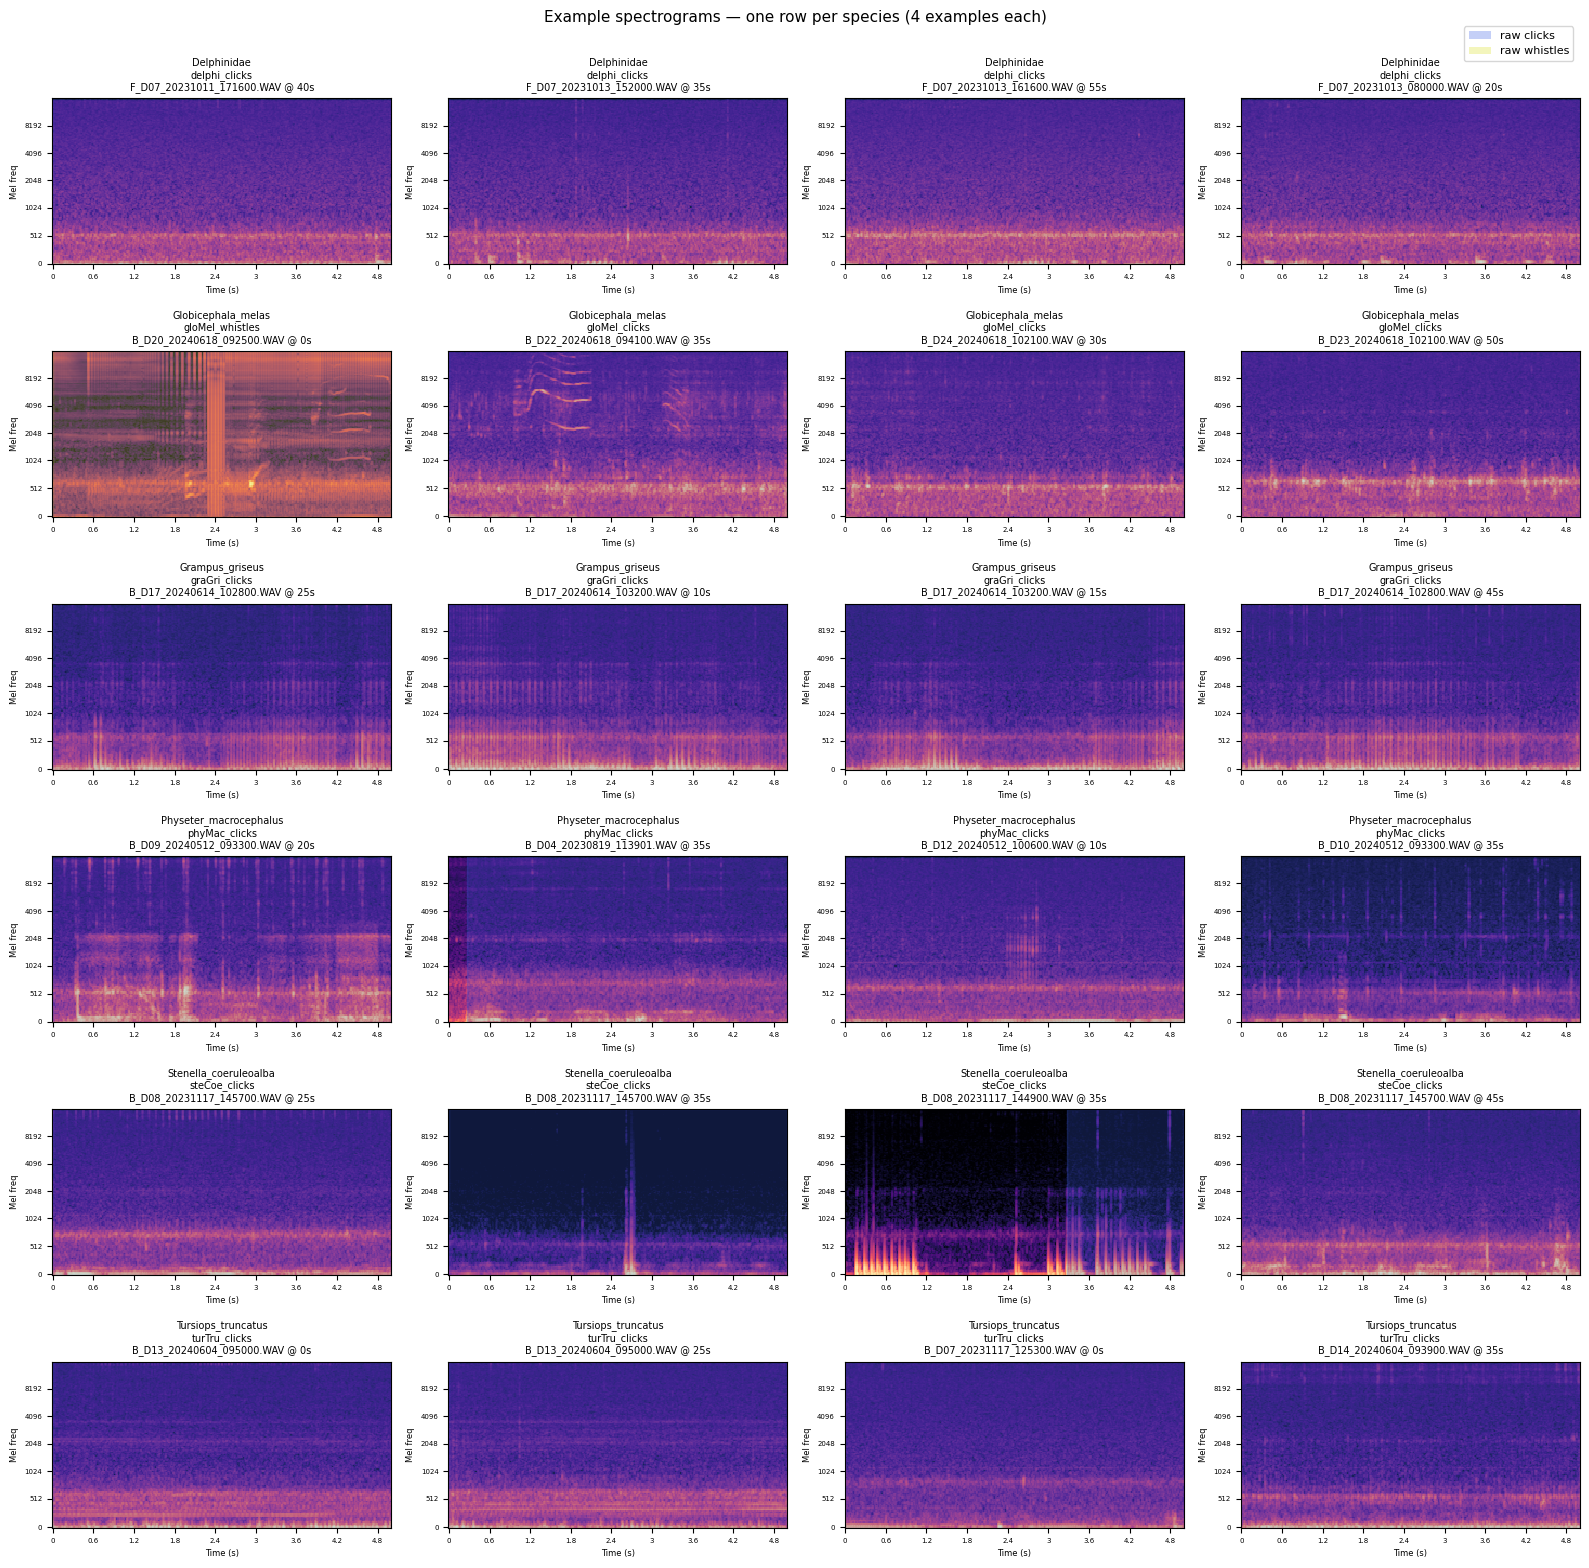

Saved to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/figures/example_spectrograms.png


In [21]:
#@title Visualize example spectrograms — one row per species

from matplotlib.patches import Patch
import librosa.display

n_examples = 4
min_display_width = 0.08
random_seed_viz = 42

# Color annotations by signal type (we only have clicks and whistles)
signal_colors = {
    'clicks':   "#3c61e7",
    'whistles': "#dae021",
}

# Map species folder -> short code present in our window labels
# (so we can filter windows that actually contain that species' vocalizations)
folder_to_code = {
    'Tursiops_truncatus':     'turTru',
    'Globicephala_melas':     'gloMel',
    'Grampus_griseus':        'graGri',
    'Stenella_coeruleoalba':  'steCoe',
    'Physeter_macrocephalus': 'phyMac',
    'Delphinidae':            'delphi',
}

species_folders = sorted(windows_df['species_folder'].unique())

fig, axes = plt.subplots(len(species_folders), n_examples,
                         figsize=(4 * n_examples, 2.6 * len(species_folders)))
if len(species_folders) == 1:
    axes = axes[np.newaxis, :]

for row_idx, species_folder in enumerate(species_folders):
    code = folder_to_code.get(species_folder)
    pool = windows_df[windows_df['species_folder'] == species_folder]

    # Prefer windows where THIS species is actually vocalizing
    if code:
        positives = pool[pool['species_set'].str.contains(
            rf'(?:^|\|){code}(?:\||$)', regex=True, na=False)]
        # Further prefer single-species examples for cleanliness
        clean = positives[positives['n_species'] == 1]
        candidates = clean if len(clean) >= n_examples else positives
    else:
        candidates = pool[pool['n_species'] > 0]

    # Fallback: if still empty (e.g. species folder has no positives in windows), use anything
    if len(candidates) == 0:
        candidates = pool

    n_avail = min(n_examples, len(candidates))
    samples = candidates.sample(n_avail, random_state=random_seed_viz) if n_avail else None

    for col_idx in range(n_examples):
        ax = axes[row_idx][col_idx]
        if samples is None or col_idx >= n_avail:
            ax.axis('off')
            continue

        row = samples.iloc[col_idx]

        audio_native, native_sr = librosa.load(
            row['wav_path'], sr=None,
            offset=row['offset_s'], duration=window_size_s, mono=True
        )
        audio = soxr.resample(audio_native, native_sr, sr) if native_sr != sr else audio_native

        S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=sr // 2)
        S_db = librosa.power_to_db(S, ref=np.max)
        librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=ax)

        # Overlay raw annotations falling inside this window
        wav_name = Path(row['wav_path']).name
        win_start = row['offset_s']
        win_end = win_start + window_size_s

        for (ls, le, species_codes, sig, _dep) in events_per_wav.get(wav_name, []):
            if le < win_start or ls > win_end:
                continue
            a_start = max(ls, win_start) - win_start
            a_end = min(le, win_end) - win_start
            if a_end > a_start:
                width = max(a_end - a_start, min_display_width)
                center = (a_start + a_end) / 2
                color = signal_colors.get(sig, "#04AFFF")
                ax.axvspan(center - width / 2, center + width / 2,
                           color=color, alpha=0.25)

        label_short = row['label'] if len(row['label']) <= 35 else row['label'][:32] + '…'
        ax.set_title(
            f'{species_folder}\n{label_short}\n{wav_name} @ {row["offset_s"]:.0f}s',
            fontsize=7
        )
        ax.set_xlabel('Time (s)', fontsize=6)
        ax.set_ylabel('Mel freq', fontsize=6)
        ax.tick_params(axis='both', labelsize=5)

fig.legend(handles=[Patch(facecolor=v, alpha=0.3, label=f'raw {k}')
                    for k, v in signal_colors.items()],
           loc='upper right', fontsize=8, bbox_to_anchor=(0.99, 0.995))

plt.suptitle(f'Example spectrograms — one row per species ({n_examples} examples each)',
             fontsize=11, y=1.002)
plt.tight_layout()

os.makedirs(f'{save_dir}/figures', exist_ok=True)
out_path = f'{save_dir}/figures/example_spectrograms.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {out_path}')

# retrieving the data and performing zero-shot and fully-supervised classifications

In [9]:
import numpy as np
import pandas as pd

X_clean      = np.load(f'{save_dir}/embeddings/X_embeddings.npy')
Z_clean      = np.load(f'{save_dir}/embeddings/Z_logits.npy')
metadata_clean = pd.read_csv(f'{save_dir}/embeddings/metadata.csv')

# ── Join deployment metadata ──────────────────────────────────────────
supp = pd.read_excel(f'{save_dir}/embeddings/Supplementary_table.xlsx')
supp['bottomDepth (m)'] = supp['bottomDepth (m)'].abs()

metadata_clean['deployment_key'] = metadata_clean['deployment_folder'].str.replace('deployment-', '', regex=False)
metadata_clean = metadata_clean.merge(supp[['deploymentID', 'deploymentPlatform', 'bottomDepth (m)']],
                                      left_on='deployment_key', right_on='deploymentID', how='left')

# ── Assign background sublabels ───────────────────────────────────────
def assign_background_label(row):
    if row['label'] != 'background':
        return row['label']

    platform = str(row.get('deploymentPlatform', '')).strip().lower()
    depth    = row.get('bottomDepth (m)', np.nan)

    if platform in ('longline gear', 'trammel net gear'):
        return 'background_fishing_gear'
    if platform == 'anchored fad':
        return 'background_FAD_deep'
    if platform == 'boat':
        return 'background_boat_deep' if depth > 150 else 'background_boat_shallow'
    if platform == 'sailing boat':
        return 'background_sailing_deep' if depth > 150 else 'background_sailing_shallow'

    return 'background_unknown'

metadata_clean['label_refined'] = metadata_clean.apply(assign_background_label, axis=1)
y_clean = metadata_clean['label_refined'].values

# ── Overwrite ─────────────────────────────────────────────────────────
np.save(f'{save_dir}/embeddings/y_labels.npy', y_clean)
metadata_clean.to_csv(f'{save_dir}/embeddings/metadata.csv', index=False)

print(f'Clean shapes — X: {X_clean.shape}, Z: {Z_clean.shape}, y: {y_clean.shape}')
print(f'\nClass distribution:')
print(pd.Series(y_clean).value_counts().to_string())

Clean shapes — X: (5202, 1536), Z: (5202, 14795), y: (5202,)

Class distribution:
background_FAD_deep                                            2594
background_boat_deep                                            978
background_sailing_shallow                                      440
delphi_clicks                                                   304
background_sailing_deep                                         233
phyMac_clicks                                                   179
gloMel_clicks+turTru_clicks                                     106
gloMel_clicks                                                    89
background_boat_shallow                                          85
turTru_clicks                                                    58
graGri_clicks                                                    45
gloMel_whistles                                                  32
gloMel_clicks+gloMel_whistles                                    20
background_fishing_gear           

In [21]:
# ── Load supplementary metadata ──────────────────────────────────────
supp = pd.read_excel(f'{save_dir}/embeddings/Supplementary_table.xlsx')
supp['bottomDepth (m)'] = supp['bottomDepth (m)'].abs()

# ── Join background windows with deployment metadata ─────────────────
bg = metadata_clean[metadata_clean['label'] == 'background'].copy()
bg['deployment_key'] = bg['deployment_folder'].str.replace('deployment-', '', regex=False)
bg = bg.merge(supp, left_on='deployment_key', right_on='deploymentID', how='left')

print(f'Background windows: {len(bg)}')
print(f'Matched to metadata: {bg["deploymentID"].notna().sum()}')
print(f'Unmatched: {bg["deploymentID"].isna().sum()}')

# ── Distribution by platform ──────────────────────────────────────────
print('\n=== deploymentPlatform ===')
print(bg['deploymentPlatform'].value_counts().to_string())

print('\n=== deploymentType ===')
print(bg['deploymentType'].value_counts().to_string())

print('\n=== site ===')
print(bg['site'].value_counts().to_string())

# ── Bottom depth bins ─────────────────────────────────────────────────
bg['depth_bin'] = pd.cut(bg['bottomDepth (m)'],
                          bins=[0, 50, 150, 500, 2000],
                          labels=['<50m', '50-150m', '150-500m', '>500m'])
print('\n=== bottomDepth bins ===')
print(bg['depth_bin'].value_counts().sort_index().to_string())

# ── Cross-tab: platform × depth bin ──────────────────────────────────
print('\n=== platform × depth bin ===')
print(pd.crosstab(bg['deploymentPlatform'], bg['depth_bin']).to_string())

Background windows: 4348
Matched to metadata: 4348
Unmatched: 0

=== deploymentPlatform ===
deploymentPlatform
anchored FAD        2594
boat                1063
sailing boat         673
longline gear         10
trammel net gear       8

=== deploymentType ===
deploymentType
fishing operations    2612
boat-based surveys    1736

=== site ===
site
Sóller, Mallorca island, Spain    2594
Columbretes islands, Spain         930
Balearic islands, Spain            616
Tarifa, Spain                      133
Cabrera island, Spain               65
Port Vendres, France                10

=== bottomDepth bins ===
depth_bin
<50m           0
50-150m      543
150-500m      94
>500m       3711

=== platform × depth bin ===
depth_bin           50-150m  150-500m  >500m
deploymentPlatform                          
anchored FAD              0         0   2594
boat                     85        84    894
longline gear            10         0      0
sailing boat            440        10    223
trammel net ge

In [24]:
#@title Zero-shot species analysis — what does Perch think your sounds are?

class_names_list = list(embedding_model.class_list['labels'].classes)

# Align labels with the kept embeddings (in case some windows failed during embedding)
windows_kept = windows_df.loc[kept_idx].reset_index(drop=True)

# -------- Build analysis buckets --------
masks = {'background': y == 'background'}

# Per-species buckets: any window where this species vocalized
species_codes_present = sorted(set(
    c for s in windows_kept['species_set'] if s for c in s.split('|')
))
for code in species_codes_present:
    pattern = rf'(?:^|\|){re.escape(code)}(?:\||$)'
    masks[f'{code}'] = windows_kept['species_set'].str.contains(pattern, regex=True, na=False).values

# Per-signal-type buckets: any window containing this signal type
for sig in ['clicks', 'whistles']:
    pattern = rf'(?:^|\|){re.escape(sig)}(?:\||$)'
    masks[f'sig:{sig}'] = windows_kept['signal_set'].str.contains(pattern, regex=True, na=False).values

# Only keep buckets that have samples
mean_logits = {name: Z[mask].mean(axis=0) for name, mask in masks.items() if mask.sum() > 0}

# -------- Top-k per bucket --------
for name, logits in mean_logits.items():
    top_idx = np.argsort(logits)[::-1][:20]
    n = masks[name].sum()
    print(f'TOP 20 PERCH CLASSES FOR "{name}" WINDOWS (n={n}):')
    print('-' * 50)
    for idx in top_idx:
        print(f'  {logits[idx]:6.3f}  {class_names_list[idx]}')
    print()

# -------- Candidate comparison --------
dolphin_candidates = {}
for name in ['Tursiops truncatus']:
    if name in class_names_list:
        dolphin_candidates[name] = class_names_list.index(name)
    else:
        print(f'  [WARN] "{name}" not found in Perch class list — skipping')

background_candidates = {}
for name in ['Water', 'Ocean', 'Boat_and_Water_vehicle']:
    if name in class_names_list:
        background_candidates[name] = class_names_list.index(name)
    else:
        print(f'  [WARN] "{name}" not found in Perch class list — skipping')


def print_candidate_table(title, candidates):
    if not candidates:
        print(f'{title}: no valid candidates found.\n')
        return

    bucket_names = list(mean_logits.keys())
    name_w = 30
    col_w = 18  # room for "  +2.345 (#1234)"

    print(f'\n{title}')
    sep = '-' * (name_w + col_w * len(bucket_names))
    print(sep)
    header = f'  {"Class":{name_w-2}s}' + ''.join(f'{b:>{col_w}s}' for b in bucket_names)
    print(header)
    print(sep)
    for cname, idx in candidates.items():
        row = f'  {cname:{name_w-2}s}'
        for b in bucket_names:
            logits = mean_logits[b]
            rank = int(np.where(np.argsort(logits)[::-1] == idx)[0][0]) + 1
            row += f'{logits[idx]:+6.2f} (#{rank:<5d})'.rjust(col_w)
        print(row)
    print()


print_candidate_table('DOLPHIN CANDIDATES — mean logit per bucket:', dolphin_candidates)
print_candidate_table('BACKGROUND CANDIDATES — mean logit per bucket:', background_candidates)

TOP 20 PERCH CLASSES FOR "background" WINDOWS (n=4348):
--------------------------------------------------
   6.348  Strix aluco
   5.878  Strix varia
   5.645  Bubo bubo
   5.224  Strix uralensis
   5.079  Metaplastes ornatus
   4.984  Asio otus
   4.945  Bubo virginianus
   4.837  Tyto alba
   4.835  Caprimulgus europaeus
   4.830  Dryocopus martius
   4.826  Botaurus stellaris
   4.791  Coturnix coturnix
   4.747  Aegolius funereus
   4.698  Rallus aquaticus
   4.653  Nycticorax nycticorax
   4.602  Corvus corax
   4.508  Ardea cinerea
   4.506  Turdus merula
   4.498  Erithacus rubecula
   4.467  Columba palumbus

TOP 20 PERCH CLASSES FOR "delphi" WINDOWS (n=307):
--------------------------------------------------
   6.763  Strix aluco
   6.673  Strix varia
   6.325  Bubo bubo
   6.046  Strix uralensis
   5.799  Metaplastes ornatus
   5.503  Asio otus
   5.308  Tyto alba
   5.249  Caprimulgus europaeus
   5.239  Botaurus stellaris
   5.229  Aegolius funereus
   5.213  Coturnix cotu

In [44]:
#@title Train / test split — clean labels + downsample bg + stratified window split

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter
import numpy as np

#@markdown How much larger than the biggest non-background class should background be?
bg_multiplier = 2.0  #@param {type:'number'}

# -------- 1. Align with embeddings --------
windows_kept = windows_df.loc[kept_idx].reset_index(drop=True).copy()
if 'y_raw' not in globals():
    y_raw = np.array(y)
assert len(windows_kept) == len(X) == len(y_raw) == len(Z), \
    f'Misaligned: wk={len(windows_kept)} X={len(X)} y={len(y_raw)} Z={len(Z)}'

y_work = np.array(y_raw)
X_work = X.copy()
Z_work = Z.copy()

# -------- 2. Drop rare atomic classes --------
drop_classes = {'delphi_whistles'}
drop_mask = ~np.isin(y_work, list(drop_classes))
windows_kept = windows_kept.loc[drop_mask].reset_index(drop=True)
X_work, Z_work, y_work = X_work[drop_mask], Z_work[drop_mask], y_work[drop_mask]
print(f'After dropping {drop_classes}: {len(y_work)} windows')

# -------- 3. Merge rare compound classes + manual renames --------
min_class_size = 10
label_counts = Counter(y_work)
remap = {}
for lbl, count in label_counts.items():
    if lbl == 'background' or count >= min_class_size:
        continue
    components = lbl.split('+')
    if len(components) == 1:
        continue
    component_counts = {c: label_counts.get(c, 0) for c in components}
    remap[lbl] = min(component_counts.items(), key=lambda x: x[1])[0]

manual_rename = {'turTru_whistles': 'turTru', 'turTru_clicks': 'turTru'}
full_remap = {**remap, **manual_rename}
y_work = np.array([full_remap.get(lbl, lbl) for lbl in y_work])
windows_kept['label'] = y_work

print(f'Remap: {full_remap}')

# -------- 4. Downsample background proportionately per WAV --------
rng = np.random.default_rng(random_seed)
is_bg = (y_work == 'background')
pos_counts = Counter(y_work[~is_bg])
max_pos_class, max_pos_count = max(pos_counts.items(), key=lambda x: x[1])
target_bg = int(bg_multiplier * max_pos_count)

print(f'\nBefore downsample: {is_bg.sum()} bg, {(~is_bg).sum()} pos')
print(f'Largest pos class: {max_pos_class} ({max_pos_count})')
print(f'Target bg: {target_bg} ({bg_multiplier}× largest pos)')

if target_bg < is_bg.sum():
    bg_by_wav = windows_kept.loc[is_bg].groupby('wav_path').indices
    total_bg = sum(len(v) for v in bg_by_wav.values())
    keep_indices = []
    for wav_path, row_idxs in bg_by_wav.items():
        share = len(row_idxs) / total_bg
        target = target_bg * share
        lo = int(np.floor(target))
        take_extra = rng.random() < (target - lo)
        n_keep = min(lo + (1 if take_extra else 0), len(row_idxs))
        if n_keep > 0:
            keep_indices.extend(rng.choice(row_idxs, size=n_keep, replace=False))

    keep_mask = ~is_bg.copy()
    keep_mask[keep_indices] = True
    windows_kept = windows_kept.loc[keep_mask].reset_index(drop=True)
    X_work, Z_work, y_work = X_work[keep_mask], Z_work[keep_mask], y_work[keep_mask]

print(f'After downsample: {(y_work == "background").sum()} bg, {(y_work != "background").sum()} pos')

print('\nFinal class distribution:')
for lbl, c in sorted(Counter(y_work).items(), key=lambda x: -x[1]):
    print(f'  {lbl:40s}  {c}')

# -------- 5. Label encoding --------
le = LabelEncoder()
y_enc = le.fit_transform(y_work)
class_names = list(le.classes_)
n_classes = len(class_names)
print(f'\n{n_classes} classes')

# -------- 6. Stratified window-level split --------
idx_train, idx_test = train_test_split(
    np.arange(len(y_enc)),
    test_size=test_size,
    stratify=y_enc,
    random_state=random_seed,
)
train_mask = np.zeros(len(y_enc), dtype=bool)
test_mask = np.zeros(len(y_enc), dtype=bool)
train_mask[idx_train] = True
test_mask[idx_test] = True

X_train, y_train, Z_train = X_work[train_mask], y_enc[train_mask], Z_work[train_mask]
X_test,  y_test,  Z_test  = X_work[test_mask],  y_enc[test_mask],  Z_work[test_mask]

# -------- 7. Reports --------
print(f'\nTrain: {train_mask.sum()} | Test: {test_mask.sum()}')
print('\n=== Per-class coverage ===')
for cn in class_names:
    n_tr = (le.inverse_transform(y_train) == cn).sum()
    n_te = (le.inverse_transform(y_test) == cn).sum()
    total = n_tr + n_te
    print(f'  {cn:40s}  train={n_tr:>4d}  test={n_te:>4d}  ({n_te/total:.0%})')

# Expose under canonical names
X, Z, y = X_work, Z_work, y_work

After dropping {'delphi_whistles'}: 5199 windows
Remap: {'turTru_whistles': 'turTru', 'turTru_clicks': 'turTru'}

Before downsample: 4348 bg, 851 pos
Largest pos class: delphi_clicks (304)
Target bg: 608 (2.0× largest pos)
After downsample: 508 bg, 851 pos

Final class distribution:
  background                                508
  delphi_clicks                             304
  phyMac_clicks                             179
  gloMel_clicks+turTru_clicks               106
  gloMel_clicks                             89
  turTru                                    61
  graGri_clicks                             45
  gloMel_whistles                           32
  gloMel_clicks+gloMel_whistles             20
  steCoe_clicks                             15

10 classes

Train: 951 | Test: 408

=== Per-class coverage ===
  background                                train= 355  test= 153  (30%)
  delphi_clicks                             train= 213  test=  91  (30%)
  gloMel_clicks                 

In [46]:
#@title Train classifiers + track metrics (multiclass)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import time

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=random_seed, class_weight='balanced', n_jobs=-1,
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, random_state=random_seed, class_weight='balanced',
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, random_state=random_seed, class_weight='balanced', n_jobs=-1,
    ),
   # SVM on ~5k x 1280 with probability=True is slow (5-15 min). Uncomment if curious:
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', random_state=random_seed, probability=True,
    ),
}

n_classes = len(class_names)
y_test_1h = label_binarize(y_test, classes=list(range(n_classes)))

results = {}

for name, clf in classifiers.items():
    print(f'\nTraining {name}...')
    t0 = time.time()

    clf.fit(X_train_sc, y_train)
    y_pred  = clf.predict(X_test_sc)
    y_proba = clf.predict_proba(X_test_sc)
    elapsed = time.time() - t0

    f1_macro    = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=range(n_classes), zero_division=0)
    train_acc = clf.score(X_train_sc, y_train)
    test_acc  = clf.score(X_test_sc,  y_test)

    # Multiclass AUC: one-vs-rest, macro-averaged over classes present in test
    # (roc_auc_score fails if a class is absent from y_test, so we filter)
    present = np.where(y_test_1h.sum(axis=0) > 0)[0]
    try:
        auc_ovr = roc_auc_score(
            y_test_1h[:, present], y_proba[:, present],
            average='macro', multi_class='ovr',
        )
    except Exception as e:
        auc_ovr = float('nan')
        print(f'  AUC failed: {e}')

    results[name] = {
        'clf': clf, 'y_pred': y_pred, 'y_proba': y_proba,
        'f1_macro': f1_macro, 'f1_weighted': f1_weighted, 'f1_per_class': f1_per_class,
        'train_acc': train_acc, 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed,
    }

    print(f'  Time: {elapsed:.1f}s | Train: {train_acc:.4f} | Test: {test_acc:.4f} | '
          f'Macro F1: {f1_macro:.4f} | Weighted F1: {f1_weighted:.4f} | OvR AUC: {auc_ovr:.4f}')
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# -------- Summary --------
print('\n' + '=' * 96)
print('SUMMARY')
print('=' * 96)
hdr = f'{"Classifier":<22} {"MacroF1":>8} {"WgtF1":>8} {"OvR AUC":>8} {"Train":>8} {"Test":>8} {"Gap":>6} {"Time":>7}'
print(hdr)
print('-' * 96)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<22} {res["f1_macro"]:>8.4f} {res["f1_weighted"]:>8.4f} '
          f'{res["auc_ovr"]:>8.4f} {res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} '
          f'{gap:>6.4f} {res["time_s"]:>6.1f}s')

# -------- Per-class F1 table --------
print('\n' + '=' * 96)
print('PER-CLASS F1')
print('=' * 96)

# Truncate long compound labels in header for readability
def short(lbl, n=14):
    return lbl if len(lbl) <= n else lbl[:n-1] + '…'

header = f'{"Classifier":<22}' + ''.join(f' {short(cn):>14s}' for cn in class_names)
print(header)
print('-' * len(header))
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    row = f'{name:<22}' + ''.join(f' {f1:>14.4f}' for f1 in res['f1_per_class'])
    print(row)

# Test-set support per class (helps interpret zero F1s)
print('\nTest-set support per class:')
for i, cn in enumerate(class_names):
    n = (y_test == i).sum()
    print(f'  {cn:40s}  {n}')


Training Logistic Regression...
  Time: 3.3s | Train: 1.0000 | Test: 0.6740 | Macro F1: 0.7297 | Weighted F1: 0.6703 | OvR AUC: 0.9511
                               precision    recall  f1-score   support

                   background       0.62      0.53      0.57       153
                delphi_clicks       0.56      0.64      0.59        91
                gloMel_clicks       0.63      0.81      0.71        27
gloMel_clicks+gloMel_whistles       1.00      0.50      0.67         6
  gloMel_clicks+turTru_clicks       0.82      0.97      0.89        32
              gloMel_whistles       0.78      0.70      0.74        10
                graGri_clicks       0.80      0.92      0.86        13
                phyMac_clicks       0.86      0.81      0.84        54
                steCoe_clicks       1.00      0.50      0.67         4
                       turTru       0.71      0.83      0.77        18

                     accuracy                           0.67       408
          

We will go pure species level, ignore signal types

In [47]:
#@title Variation: species-level classification (collapse signal types)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import time


def to_species_label(lbl):
    """'gloMel_clicks+turTru_clicks' -> 'gloMel+turTru'
       'gloMel_clicks+gloMel_whistles' -> 'gloMel'
       'background' stays 'background'."""
    if lbl == 'background':
        return 'background'
    species = set(atom.split('_')[0] for atom in lbl.split('+'))
    return '+'.join(sorted(species))


# -------- Relabel everything (train + test) at the species level --------
y_train_names = le.inverse_transform(y_train)
y_test_names  = le.inverse_transform(y_test)

y_train_sp_names = np.array([to_species_label(l) for l in y_train_names])
y_test_sp_names  = np.array([to_species_label(l) for l in y_test_names])

# Fresh label encoder for species-level
le_sp = LabelEncoder()
# Fit on union of train+test so indices are consistent
le_sp.fit(np.concatenate([y_train_sp_names, y_test_sp_names]))
class_names_sp = list(le_sp.classes_)
n_classes_sp = len(class_names_sp)

y_train_sp = le_sp.transform(y_train_sp_names)
y_test_sp  = le_sp.transform(y_test_sp_names)

print(f'Species-level classes ({n_classes_sp}): {class_names_sp}')
print('\nTrain distribution:')
for lbl, c in sorted(Counter(y_train_sp_names).items(), key=lambda x: -x[1]):
    print(f'  {lbl:30s}  {c}')
print('\nTest distribution:')
for lbl, c in sorted(Counter(y_test_sp_names).items(), key=lambda x: -x[1]):
    print(f'  {lbl:30s}  {c}')

# -------- Reuse the already-fit scaler from the main cell (same X_train/X_test) --------
X_train_sc = scaler.transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Same classifier lineup as the main cell
classifiers_sp = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=random_seed, class_weight='balanced', n_jobs=-1,
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, random_state=random_seed, class_weight='balanced',
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, random_state=random_seed, class_weight='balanced', n_jobs=-1,
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', random_state=random_seed, probability=True,
    ),
}

y_test_sp_1h = label_binarize(y_test_sp, classes=list(range(n_classes_sp)))

results_sp = {}

for name, clf in classifiers_sp.items():
    print(f'\nTraining {name} (species)...')
    t0 = time.time()
    clf.fit(X_train_sc, y_train_sp)
    y_pred = clf.predict(X_test_sc)
    y_proba = clf.predict_proba(X_test_sc)
    elapsed = time.time() - t0

    f1_macro     = f1_score(y_test_sp, y_pred, average='macro')
    f1_weighted  = f1_score(y_test_sp, y_pred, average='weighted')
    f1_per_class = f1_score(y_test_sp, y_pred, average=None,
                            labels=range(n_classes_sp), zero_division=0)
    train_acc = clf.score(X_train_sc, y_train_sp)
    test_acc  = clf.score(X_test_sc,  y_test_sp)

    present = np.where(y_test_sp_1h.sum(axis=0) > 0)[0]
    try:
        auc_ovr = roc_auc_score(
            y_test_sp_1h[:, present], y_proba[:, present],
            average='macro', multi_class='ovr',
        )
    except Exception as e:
        auc_ovr = float('nan')
        print(f'  AUC failed: {e}')

    results_sp[name] = {
        'clf': clf, 'y_pred': y_pred, 'y_proba': y_proba,
        'f1_macro': f1_macro, 'f1_weighted': f1_weighted, 'f1_per_class': f1_per_class,
        'train_acc': train_acc, 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed,
    }

    print(f'  Time: {elapsed:.1f}s | Train: {train_acc:.4f} | Test: {test_acc:.4f} | '
          f'Macro F1: {f1_macro:.4f} | Weighted F1: {f1_weighted:.4f} | OvR AUC: {auc_ovr:.4f}')
    print(classification_report(y_test_sp, y_pred, target_names=class_names_sp, zero_division=0))

# -------- Summary --------
print('\n' + '=' * 96)
print('SUMMARY — SPECIES-LEVEL')
print('=' * 96)
hdr = f'{"Classifier":<22} {"MacroF1":>8} {"WgtF1":>8} {"OvR AUC":>8} {"Train":>8} {"Test":>8} {"Gap":>6} {"Time":>7}'
print(hdr)
print('-' * 96)
for name, res in sorted(results_sp.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<22} {res["f1_macro"]:>8.4f} {res["f1_weighted"]:>8.4f} '
          f'{res["auc_ovr"]:>8.4f} {res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} '
          f'{gap:>6.4f} {res["time_s"]:>6.1f}s')

# -------- Per-class F1 table --------
print('\n' + '=' * 96)
print('PER-CLASS F1 — SPECIES-LEVEL')
print('=' * 96)

def short(lbl, n=14):
    return lbl if len(lbl) <= n else lbl[:n-1] + '…'

header = f'{"Classifier":<22}' + ''.join(f' {short(cn):>14s}' for cn in class_names_sp)
print(header)
print('-' * len(header))
for name, res in sorted(results_sp.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    row = f'{name:<22}' + ''.join(f' {f1:>14.4f}' for f1 in res['f1_per_class'])
    print(row)

print('\nTest-set support per class:')
for i, cn in enumerate(class_names_sp):
    n = (y_test_sp == i).sum()
    print(f'  {cn:30s}  {n}')

# -------- Quick head-to-head against the 10-class results --------
print('\n' + '=' * 96)
print('HEAD-TO-HEAD: signal+species (main)  vs  species-only (variant)')
print('=' * 96)
print(f'{"Classifier":<22} {"MacroF1_main":>14} {"MacroF1_sp":>12} {"WgtF1_main":>12} {"WgtF1_sp":>10}')
print('-' * 72)
for name in classifiers_sp.keys():
    if name not in results:
        continue
    m = results[name]
    s = results_sp[name]
    print(f'{name:<22} {m["f1_macro"]:>14.4f} {s["f1_macro"]:>12.4f} '
          f'{m["f1_weighted"]:>12.4f} {s["f1_weighted"]:>10.4f}')

Species-level classes (8): ['background', 'delphi', 'gloMel', 'gloMel+turTru', 'graGri', 'phyMac', 'steCoe', 'turTru']

Train distribution:
  background                      355
  delphi                          213
  phyMac                          125
  gloMel                          98
  gloMel+turTru                   74
  turTru                          43
  graGri                          32
  steCoe                          11

Test distribution:
  background                      153
  delphi                          91
  phyMac                          54
  gloMel                          43
  gloMel+turTru                   32
  turTru                          18
  graGri                          13
  steCoe                          4

Training Logistic Regression (species)...
  Time: 1.0s | Train: 1.0000 | Test: 0.6642 | Macro F1: 0.7325 | Weighted F1: 0.6609 | OvR AUC: 0.9402
               precision    recall  f1-score   support

   background       0.60      0.52      0.5

In [48]:
#@title PyTorch MLP with Dropout (10-class: signal + species)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, f1_score, roc_auc_score, accuracy_score
import copy
import time

torch_mlp_configs = {
    'PyTorch MLP (128) drop=0.4': {
        'hidden': (128,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (64) drop=0.4': {
        'hidden': (64,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (256, 128) drop=0.5': {
        'hidden': (256, 128), 'dropout': 0.5, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
}

def build_mlp(input_dim, hidden_sizes, dropout, n_classes):
    layers = []
    in_dim = input_dim
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    layers.append(nn.Linear(in_dim, n_classes))
    return nn.Sequential(*layers)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

n_classes = len(class_names)
print(f'Classes ({n_classes}): {class_names}')

class_counts = np.bincount(y_train, minlength=n_classes)
class_weights = torch.tensor(
    [class_counts.sum() / (n_classes * max(c, 1)) for c in class_counts],
    dtype=torch.float32,
).to(device)
print('Class weights:')
for cn, w in zip(class_names, class_weights.cpu().numpy()):
    print(f'  {cn:40s}  {w:.3f}')

# Pre-compute one-hot test labels for multiclass AUC
y_test_1h = label_binarize(y_test, classes=list(range(n_classes)))

mlp_results = {}

for name, cfg in torch_mlp_configs.items():
    print(f'\nTraining {name}...')

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_sc, y_train, test_size=0.15,
        random_state=random_seed, stratify=y_train,
    )

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.long).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
    X_te_t  = torch.tensor(X_test_sc, dtype=torch.float32).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=cfg['batch_size'], shuffle=True)

    model     = build_mlp(X_train_sc.shape[1], cfg['hidden'], cfg['dropout'], n_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_epoch    = 0
    early_stopped = False

    t0 = time.time()

    for epoch in range(1, cfg['epochs'] + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            tr_logits  = model(X_tr_t)
            val_logits = model(X_val_t)
            tr_loss    = criterion(tr_logits,  y_tr_t).item()
            val_loss   = criterion(val_logits, y_val_t).item()
            tr_acc     = (tr_logits.argmax(1)  == y_tr_t).float().mean().item()
            val_acc    = (val_logits.argmax(1) == y_val_t).float().mean().item()

        train_losses.append(tr_loss); val_losses.append(val_loss)
        train_accs.append(tr_acc);   val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
        if patience_counter >= cfg['patience']:
            early_stopped = True
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(X_te_t)
        test_proba  = torch.softmax(test_logits, dim=1).cpu().numpy()  # [N, C]
        test_pred   = test_logits.argmax(1).cpu().numpy()

    elapsed = time.time() - t0

    f1_macro     = f1_score(y_test, test_pred, average='macro')
    f1_weighted  = f1_score(y_test, test_pred, average='weighted')
    f1_per_class = f1_score(y_test, test_pred, average=None,
                            labels=range(n_classes), zero_division=0)
    test_acc     = accuracy_score(y_test, test_pred)

    present = np.where(y_test_1h.sum(axis=0) > 0)[0]
    try:
        auc_ovr = roc_auc_score(
            y_test_1h[:, present], test_proba[:, present],
            average='macro', multi_class='ovr',
        )
    except Exception as e:
        auc_ovr = float('nan')
        print(f'  AUC failed: {e}')

    mlp_results[name] = {
        'y_pred': test_pred, 'y_proba': test_proba,
        'f1_macro': f1_macro, 'f1_weighted': f1_weighted, 'f1_per_class': f1_per_class,
        'train_acc': train_accs[-1], 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed, 'n_iter': len(train_losses),
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accs': train_accs, 'val_accs': val_accs,
        'best_epoch': best_epoch, 'early_stopped': early_stopped,
    }

    print(f'  Epochs: {len(train_losses)} | Best: {best_epoch} | Early stop: {early_stopped}')
    print(f'  Time: {elapsed:.1f}s | Train Acc: {train_accs[-1]:.4f} | Test Acc: {test_acc:.4f} | '
          f'Macro F1: {f1_macro:.4f} | Weighted F1: {f1_weighted:.4f} | OvR AUC: {auc_ovr:.4f}')
    print(classification_report(y_test, test_pred, target_names=class_names, zero_division=0))

# -------- Summary --------
print('\n' + '=' * 100)
print('PyTorch MLP SUMMARY (10-class)')
print('=' * 100)
print(f'{"Model":<40} {"MacroF1":>8} {"WgtF1":>8} {"OvRAUC":>8} {"Train":>8} {"Test":>8} {"Gap":>6} {"Ep":>5} {"Time":>8}')
print('-' * 100)
for name, res in sorted(mlp_results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<40} {res["f1_macro"]:>8.4f} {res["f1_weighted"]:>8.4f} '
          f'{res["auc_ovr"]:>8.4f} {res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} '
          f'{gap:>6.4f} {res["n_iter"]:>5} {res["time_s"]:>7.1f}s')

# -------- Per-class F1 table --------
print('\n' + '=' * 100)
print('PER-CLASS F1 — MLP (10-class)')
print('=' * 100)

def short(lbl, n=14):
    return lbl if len(lbl) <= n else lbl[:n-1] + '…'

header = f'{"Model":<40}' + ''.join(f' {short(cn):>14s}' for cn in class_names)
print(header)
print('-' * len(header))
for name, res in sorted(mlp_results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    row = f'{name:<40}' + ''.join(f' {f1:>14.4f}' for f1 in res['f1_per_class'])
    print(row)

if 'results' in dir():
    results.update(mlp_results)
    print('\n✓ MLP results merged into overall results dict (10-class).')

Using device: cuda
Classes (10): ['background', 'delphi_clicks', 'gloMel_clicks', 'gloMel_clicks+gloMel_whistles', 'gloMel_clicks+turTru_clicks', 'gloMel_whistles', 'graGri_clicks', 'phyMac_clicks', 'steCoe_clicks', 'turTru']
Class weights:
  background                                0.268
  delphi_clicks                             0.446
  gloMel_clicks                             1.534
  gloMel_clicks+gloMel_whistles             6.793
  gloMel_clicks+turTru_clicks               1.285
  gloMel_whistles                           4.323
  graGri_clicks                             2.972
  phyMac_clicks                             0.761
  steCoe_clicks                             8.645
  turTru                                    2.212

Training PyTorch MLP (128) drop=0.4...
  Epochs: 209 | Best: 179 | Early stop: True
  Time: 2.9s | Train Acc: 0.8416 | Test Acc: 0.6446 | Macro F1: 0.7048 | Weighted F1: 0.6146 | OvR AUC: 0.9493
                               precision    recall  f1-score   

In [49]:
#@title PyTorch MLP — species-level variant (relabel, reuse X_train_sc/X_test_sc)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, f1_score, roc_auc_score, accuracy_score
from collections import Counter
import copy
import time


def to_species_label(lbl):
    """Collapse 'gloMel_clicks+turTru_clicks' -> 'gloMel+turTru', etc."""
    if lbl == 'background':
        return 'background'
    species = set(atom.split('_')[0] for atom in lbl.split('+'))
    return '+'.join(sorted(species))


# -------- Relabel train + test (no re-embedding, reuse scaled features) --------
y_train_names = le.inverse_transform(y_train)
y_test_names  = le.inverse_transform(y_test)

y_train_sp_names = np.array([to_species_label(l) for l in y_train_names])
y_test_sp_names  = np.array([to_species_label(l) for l in y_test_names])

le_sp = LabelEncoder()
le_sp.fit(np.concatenate([y_train_sp_names, y_test_sp_names]))
class_names_sp = list(le_sp.classes_)
n_classes_sp = len(class_names_sp)

y_train_sp = le_sp.transform(y_train_sp_names)
y_test_sp  = le_sp.transform(y_test_sp_names)

print(f'Species-level classes ({n_classes_sp}): {class_names_sp}')
print('\nTrain distribution:')
for lbl, c in sorted(Counter(y_train_sp_names).items(), key=lambda x: -x[1]):
    print(f'  {lbl:30s}  {c}')
print('\nTest distribution:')
for lbl, c in sorted(Counter(y_test_sp_names).items(), key=lambda x: -x[1]):
    print(f'  {lbl:30s}  {c}')

# -------- MLP configs (same as 10-class) --------
torch_mlp_configs_sp = {
    'PyTorch MLP (128) drop=0.4': {
        'hidden': (128,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (64) drop=0.4': {
        'hidden': (64,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (256, 128) drop=0.5': {
        'hidden': (256, 128), 'dropout': 0.5, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
}

def build_mlp(input_dim, hidden_sizes, dropout, n_classes):
    layers = []
    in_dim = input_dim
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    layers.append(nn.Linear(in_dim, n_classes))
    return nn.Sequential(*layers)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class_counts_sp = np.bincount(y_train_sp, minlength=n_classes_sp)
class_weights_sp = torch.tensor(
    [class_counts_sp.sum() / (n_classes_sp * max(c, 1)) for c in class_counts_sp],
    dtype=torch.float32,
).to(device)
print('\nClass weights (species):')
for cn, w in zip(class_names_sp, class_weights_sp.cpu().numpy()):
    print(f'  {cn:30s}  {w:.3f}')

y_test_sp_1h = label_binarize(y_test_sp, classes=list(range(n_classes_sp)))

mlp_results_sp = {}

for name, cfg in torch_mlp_configs_sp.items():
    print(f'\nTraining {name} (species)...')

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_sc, y_train_sp, test_size=0.15,
        random_state=random_seed, stratify=y_train_sp,
    )

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.long).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
    X_te_t  = torch.tensor(X_test_sc, dtype=torch.float32).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=cfg['batch_size'], shuffle=True)

    model     = build_mlp(X_train_sc.shape[1], cfg['hidden'], cfg['dropout'], n_classes_sp).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = nn.CrossEntropyLoss(weight=class_weights_sp)

    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_epoch = 0
    early_stopped = False

    t0 = time.time()

    for epoch in range(1, cfg['epochs'] + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            tr_logits  = model(X_tr_t)
            val_logits = model(X_val_t)
            tr_loss  = criterion(tr_logits,  y_tr_t).item()
            val_loss = criterion(val_logits, y_val_t).item()
            tr_acc  = (tr_logits.argmax(1)  == y_tr_t).float().mean().item()
            val_acc = (val_logits.argmax(1) == y_val_t).float().mean().item()

        train_losses.append(tr_loss); val_losses.append(val_loss)
        train_accs.append(tr_acc);   val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
        if patience_counter >= cfg['patience']:
            early_stopped = True
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(X_te_t)
        test_proba  = torch.softmax(test_logits, dim=1).cpu().numpy()
        test_pred   = test_logits.argmax(1).cpu().numpy()

    elapsed = time.time() - t0

    f1_macro     = f1_score(y_test_sp, test_pred, average='macro')
    f1_weighted  = f1_score(y_test_sp, test_pred, average='weighted')
    f1_per_class = f1_score(y_test_sp, test_pred, average=None,
                            labels=range(n_classes_sp), zero_division=0)
    test_acc     = accuracy_score(y_test_sp, test_pred)

    present = np.where(y_test_sp_1h.sum(axis=0) > 0)[0]
    try:
        auc_ovr = roc_auc_score(
            y_test_sp_1h[:, present], test_proba[:, present],
            average='macro', multi_class='ovr',
        )
    except Exception as e:
        auc_ovr = float('nan')
        print(f'  AUC failed: {e}')

    mlp_results_sp[name] = {
        'y_pred': test_pred, 'y_proba': test_proba,
        'f1_macro': f1_macro, 'f1_weighted': f1_weighted, 'f1_per_class': f1_per_class,
        'train_acc': train_accs[-1], 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed, 'n_iter': len(train_losses),
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accs': train_accs, 'val_accs': val_accs,
        'best_epoch': best_epoch, 'early_stopped': early_stopped,
    }

    print(f'  Epochs: {len(train_losses)} | Best: {best_epoch} | Early stop: {early_stopped}')
    print(f'  Time: {elapsed:.1f}s | Train Acc: {train_accs[-1]:.4f} | Test Acc: {test_acc:.4f} | '
          f'Macro F1: {f1_macro:.4f} | Weighted F1: {f1_weighted:.4f} | OvR AUC: {auc_ovr:.4f}')
    print(classification_report(y_test_sp, test_pred, target_names=class_names_sp, zero_division=0))

# -------- Summary --------
print('\n' + '=' * 100)
print('PyTorch MLP SUMMARY — SPECIES-LEVEL')
print('=' * 100)
print(f'{"Model":<40} {"MacroF1":>8} {"WgtF1":>8} {"OvRAUC":>8} {"Train":>8} {"Test":>8} {"Gap":>6} {"Ep":>5} {"Time":>8}')
print('-' * 100)
for name, res in sorted(mlp_results_sp.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<40} {res["f1_macro"]:>8.4f} {res["f1_weighted"]:>8.4f} '
          f'{res["auc_ovr"]:>8.4f} {res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} '
          f'{gap:>6.4f} {res["n_iter"]:>5} {res["time_s"]:>7.1f}s')

# -------- Per-class F1 table --------
print('\n' + '=' * 100)
print('PER-CLASS F1 — MLP species-level')
print('=' * 100)

def short(lbl, n=14):
    return lbl if len(lbl) <= n else lbl[:n-1] + '…'

header = f'{"Model":<40}' + ''.join(f' {short(cn):>14s}' for cn in class_names_sp)
print(header)
print('-' * len(header))
for name, res in sorted(mlp_results_sp.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    row = f'{name:<40}' + ''.join(f' {f1:>14.4f}' for f1 in res['f1_per_class'])
    print(row)

# -------- Head-to-head: 10-class MLP vs species-level MLP --------
if 'mlp_results' in dir():
    print('\n' + '=' * 80)
    print('HEAD-TO-HEAD MLP: 10-class  vs  species-level')
    print('=' * 80)
    print(f'{"Model":<40} {"MacroF1_10":>12} {"MacroF1_sp":>12} {"WgtF1_10":>10} {"WgtF1_sp":>10}')
    print('-' * 80)
    for name in torch_mlp_configs_sp:
        if name not in mlp_results:
            continue
        m10 = mlp_results[name]
        msp = mlp_results_sp[name]
        print(f'{name:<40} {m10["f1_macro"]:>12.4f} {msp["f1_macro"]:>12.4f} '
              f'{m10["f1_weighted"]:>10.4f} {msp["f1_weighted"]:>10.4f}')

Species-level classes (8): ['background', 'delphi', 'gloMel', 'gloMel+turTru', 'graGri', 'phyMac', 'steCoe', 'turTru']

Train distribution:
  background                      355
  delphi                          213
  phyMac                          125
  gloMel                          98
  gloMel+turTru                   74
  turTru                          43
  graGri                          32
  steCoe                          11

Test distribution:
  background                      153
  delphi                          91
  phyMac                          54
  gloMel                          43
  gloMel+turTru                   32
  turTru                          18
  graGri                          13
  steCoe                          4

Class weights (species):
  background                      0.335
  delphi                          0.558
  gloMel                          1.213
  gloMel+turTru                   1.606
  graGri                          3.715
  phyMac           

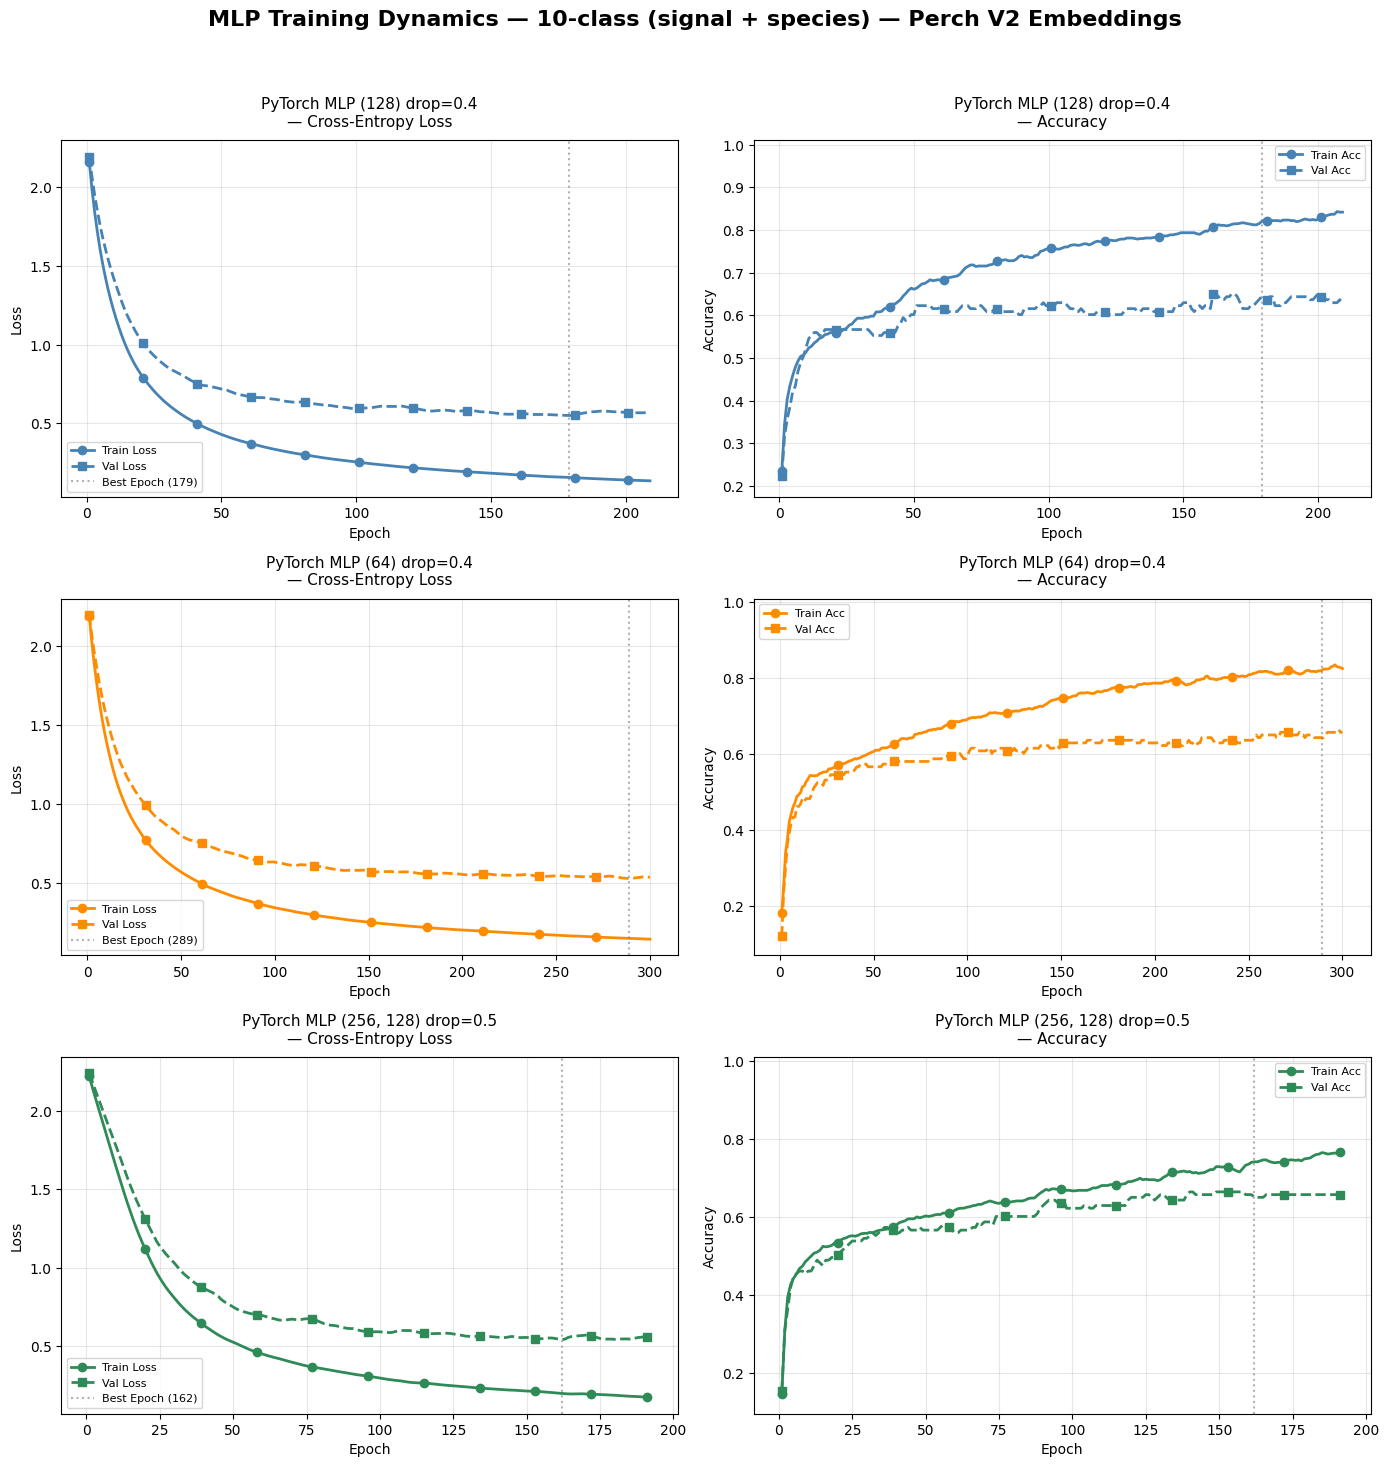

Saved to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/figures/mlp_dynamics_signal_species.png


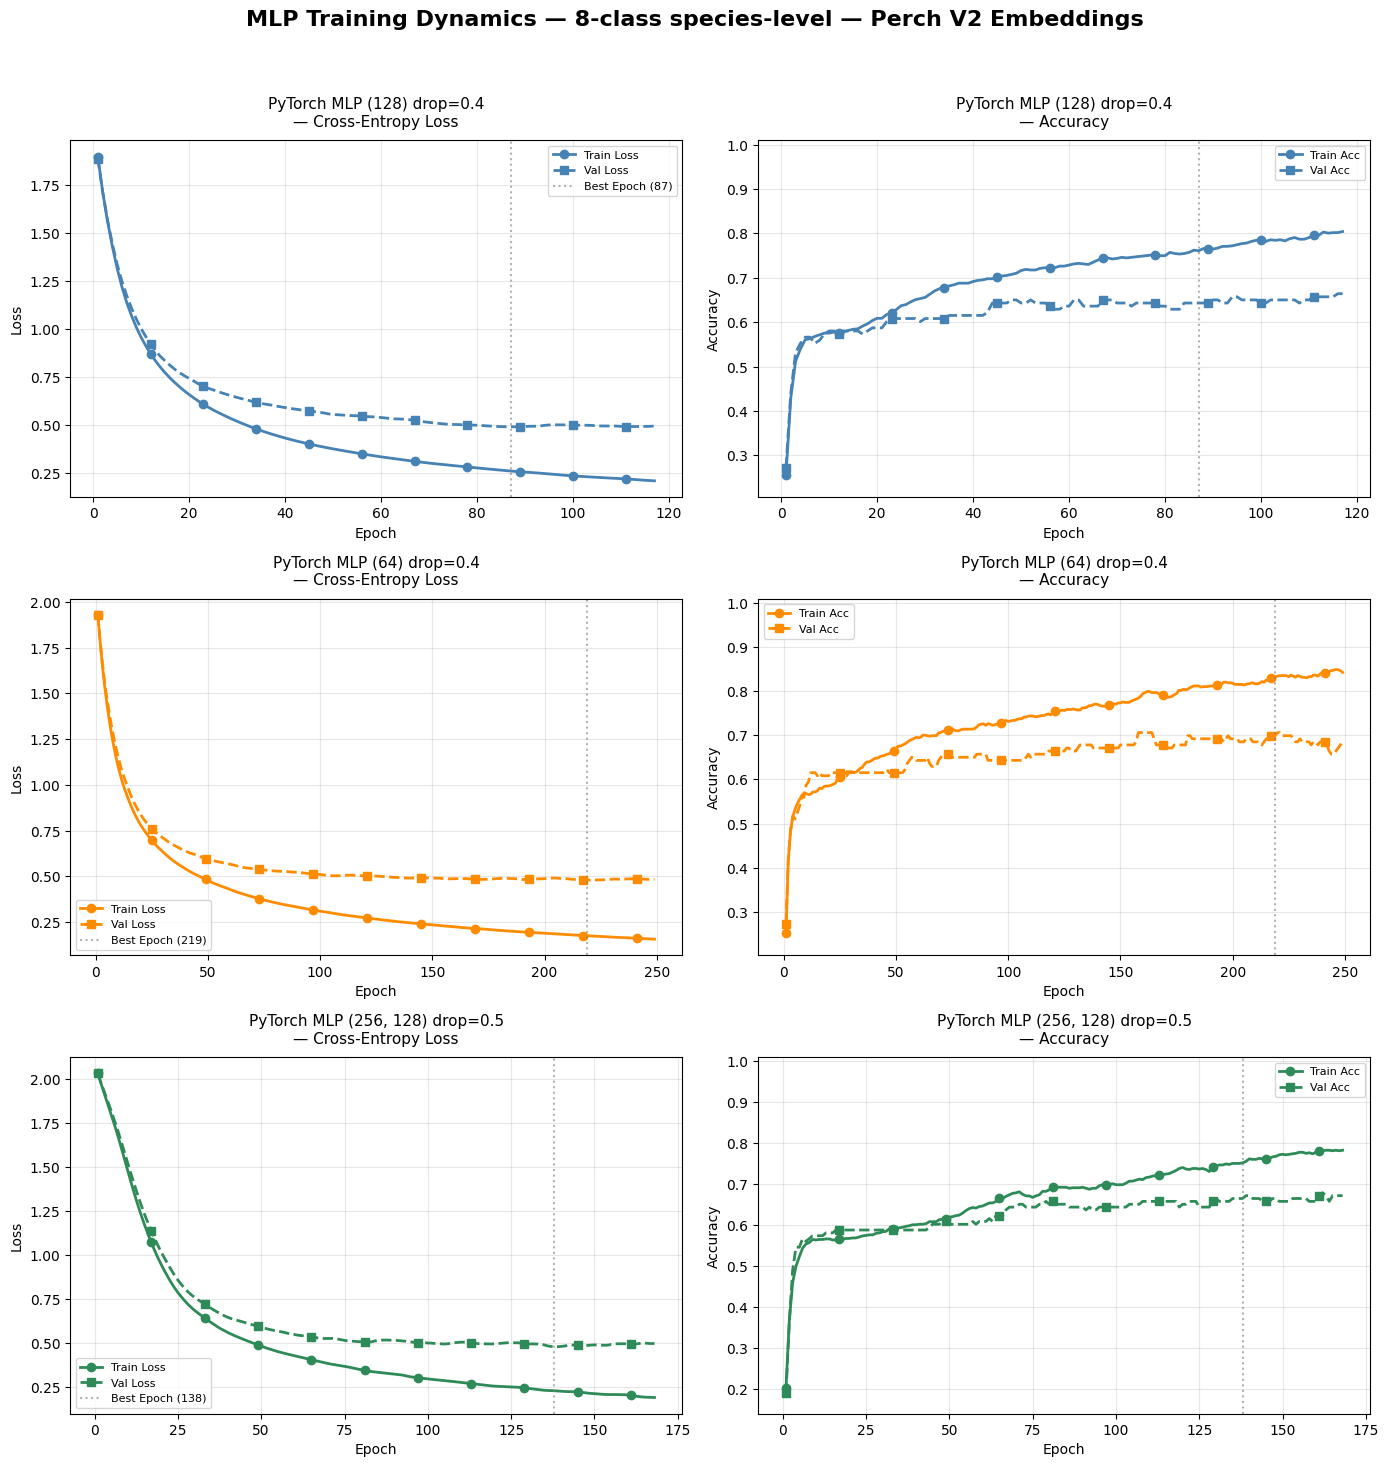

Saved to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/figures/mlp_dynamics_species_only.png


In [50]:
import matplotlib.pyplot as plt
import numpy as np
import os

color_palette = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'purple']


def plot_mlp_dynamics(results_dict, title_prefix, save_name):
    """Plot loss+accuracy curves for every model in a results dict."""
    if not results_dict:
        print(f'Skipping {title_prefix}: empty results dict')
        return

    colors = {name: color_palette[i % len(color_palette)]
              for i, name in enumerate(results_dict)}

    n_models = len(results_dict)
    fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
    if n_models == 1:
        axes = axes[np.newaxis, :]

    fig.suptitle(f'MLP Training Dynamics — {title_prefix} — Perch V2 Embeddings',
                 fontsize=16, fontweight='bold', y=0.995)

    for idx, (name, res) in enumerate(results_dict.items()):
        color = colors[name]
        epochs = np.arange(1, res['n_iter'] + 1)
        markevery = max(1, len(epochs) // 10)

        # Loss
        ax_loss = axes[idx, 0]
        ax_loss.plot(epochs, res['train_losses'], label='Train Loss',
                     color=color, linewidth=2, marker='o', markevery=markevery)
        ax_loss.plot(epochs, res['val_losses'], label='Val Loss',
                     color=color, linestyle='--', linewidth=2, marker='s', markevery=markevery)
        ax_loss.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6,
                        label=f'Best Epoch ({res["best_epoch"]})')
        ax_loss.set_title(f'{name}\n— Cross-Entropy Loss', fontsize=11, pad=10)
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Loss')
        ax_loss.legend(fontsize=8)
        ax_loss.grid(alpha=0.3)

        # Accuracy
        ax_acc = axes[idx, 1]
        ax_acc.plot(epochs, res['train_accs'], label='Train Acc',
                    color=color, linewidth=2, marker='o', markevery=markevery)
        ax_acc.plot(epochs, res['val_accs'], label='Val Acc',
                    color=color, linestyle='--', linewidth=2, marker='s', markevery=markevery)
        ax_acc.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6)
        ax_acc.set_title(f'{name}\n— Accuracy', fontsize=11, pad=10)
        ax_acc.set_xlabel('Epoch')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.legend(fontsize=8)
        ax_acc.grid(alpha=0.3)
        # Auto-scale y-axis based on actual acc range (more sensible for multiclass)
        all_acc = res['train_accs'] + res['val_accs']
        lo = max(0.0, min(all_acc) - 0.05)
        ax_acc.set_ylim(lo, 1.01)

    plt.tight_layout(rect=[0, 0.02, 1, 0.97])

    os.makedirs(f'{save_dir}/figures', exist_ok=True)
    out_path = f'{save_dir}/figures/{save_name}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {out_path}')


# -------- Plot each variant we have --------
if 'mlp_results' in dir() and mlp_results:
    plot_mlp_dynamics(
        mlp_results,
        title_prefix=f'{len(class_names)}-class (signal + species)',
        save_name='mlp_dynamics_signal_species',
    )

if 'mlp_results_sp' in dir() and mlp_results_sp:
    plot_mlp_dynamics(
        mlp_results_sp,
        title_prefix=f'{len(class_names_sp)}-class species-level',
        save_name='mlp_dynamics_species_only',
    )

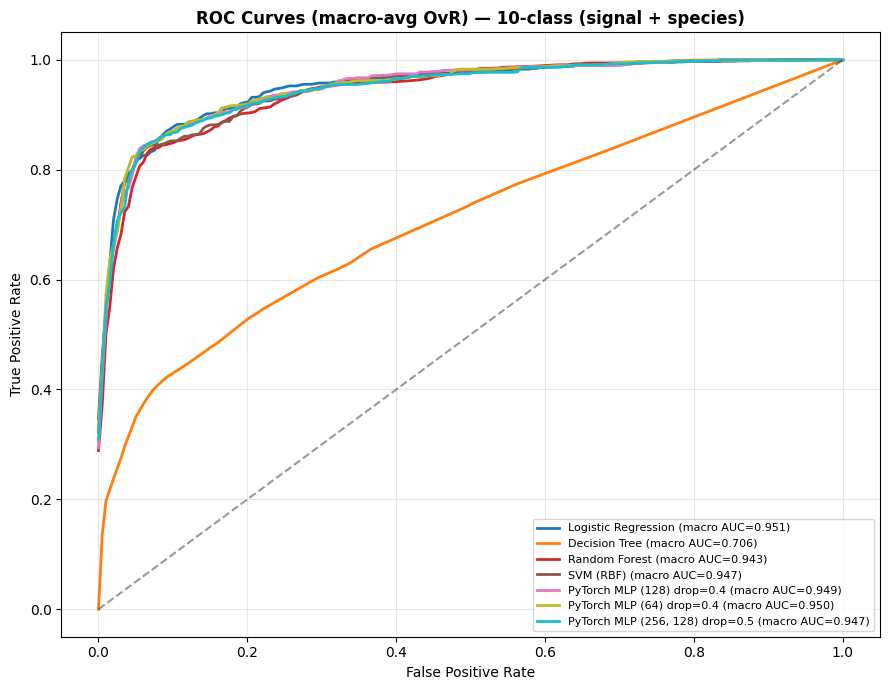

Saved to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/figures/roc_curves_signal_species.png


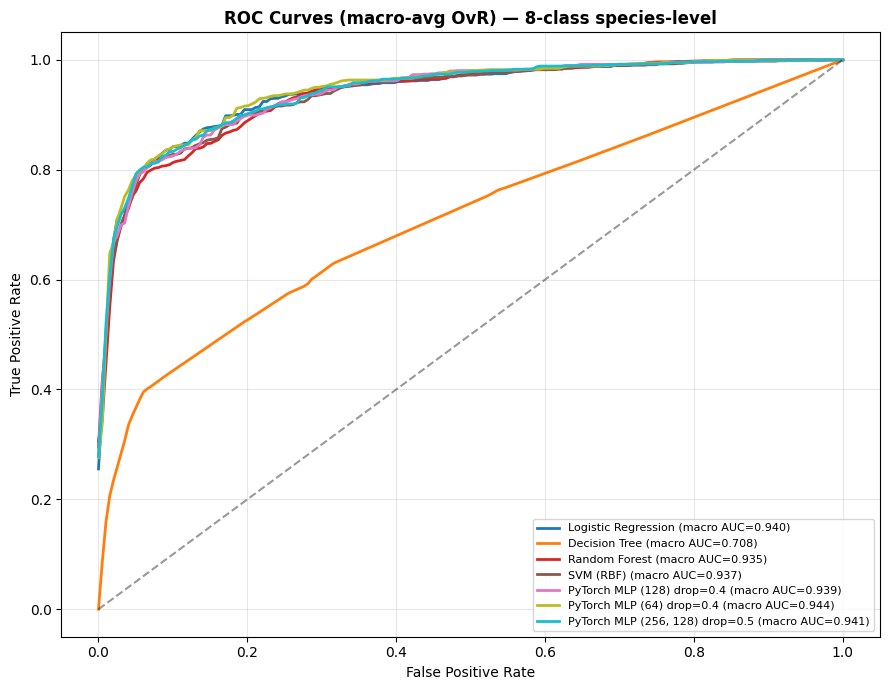

Saved to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/figures/roc_curves_species_only.png


In [51]:
#@title ROC Curves — ALL classifiers (multiclass, per variant)

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np


def plot_multiclass_roc(sk_results, mlp_results_dict, y_test_arr, class_names_arr,
                        variant_name, save_name):
    all_res = {**sk_results, **mlp_results_dict}
    n_classes = len(class_names_arr)
    y_test_1h = label_binarize(y_test_arr, classes=list(range(n_classes)))
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_res)))

    fig, ax = plt.subplots(figsize=(9, 7))

    for (name, res), color in zip(all_res.items(), colors):
        proba = res['y_proba']  # [N, C]
        # Macro-average ROC across classes present in test
        present = np.where(y_test_1h.sum(axis=0) > 0)[0]
        all_fpr = np.linspace(0, 1, 200)
        mean_tpr = np.zeros_like(all_fpr)
        for ci in present:
            fpr, tpr, _ = roc_curve(y_test_1h[:, ci], proba[:, ci])
            mean_tpr += np.interp(all_fpr, fpr, tpr)
        mean_tpr /= len(present)
        try:
            auc = roc_auc_score(y_test_1h[:, present], proba[:, present],
                                average='macro', multi_class='ovr')
        except Exception:
            auc = float('nan')
        ax.plot(all_fpr, mean_tpr, label=f'{name} (macro AUC={auc:.3f})',
                color=color, linewidth=2)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves (macro-avg OvR) — {variant_name}',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    out = f'{save_dir}/figures/{save_name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {out}')


# 10-class
if 'results' in dir() and 'mlp_results' in dir():
    plot_multiclass_roc(
        results, mlp_results, y_test, class_names,
        variant_name=f'{len(class_names)}-class (signal + species)',
        save_name='roc_curves_signal_species',
    )

# species-only
if 'results_sp' in dir() and 'mlp_results_sp' in dir():
    plot_multiclass_roc(
        results_sp, mlp_results_sp, y_test_sp, class_names_sp,
        variant_name=f'{len(class_names_sp)}-class species-level',
        save_name='roc_curves_species_only',
    )

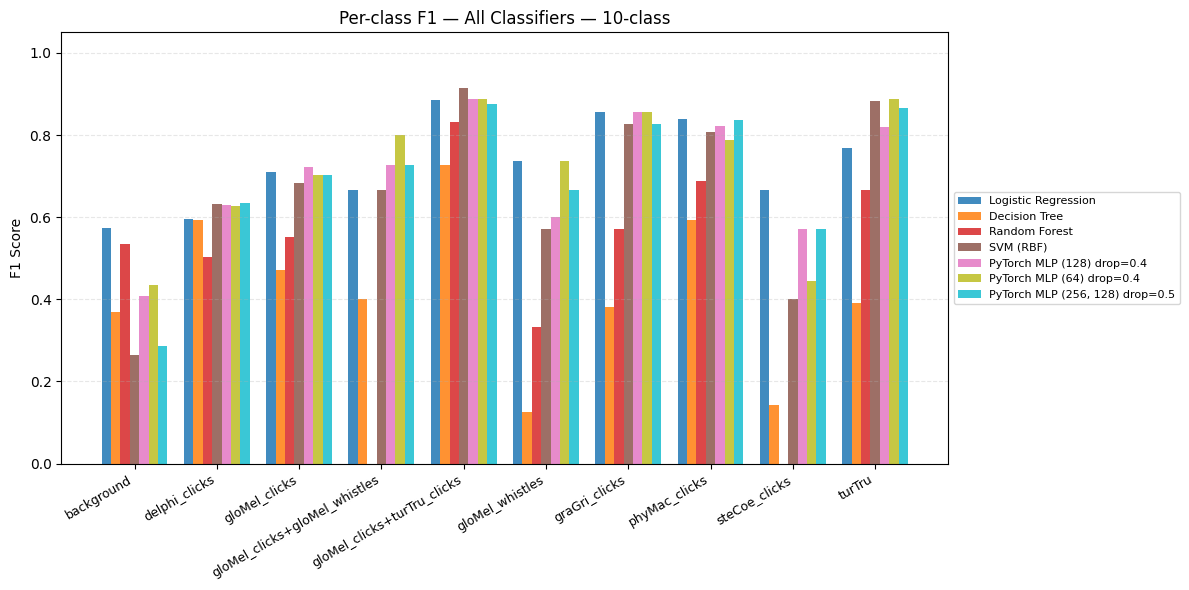

Saved to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/figures/f1_per_class_signal_species.png


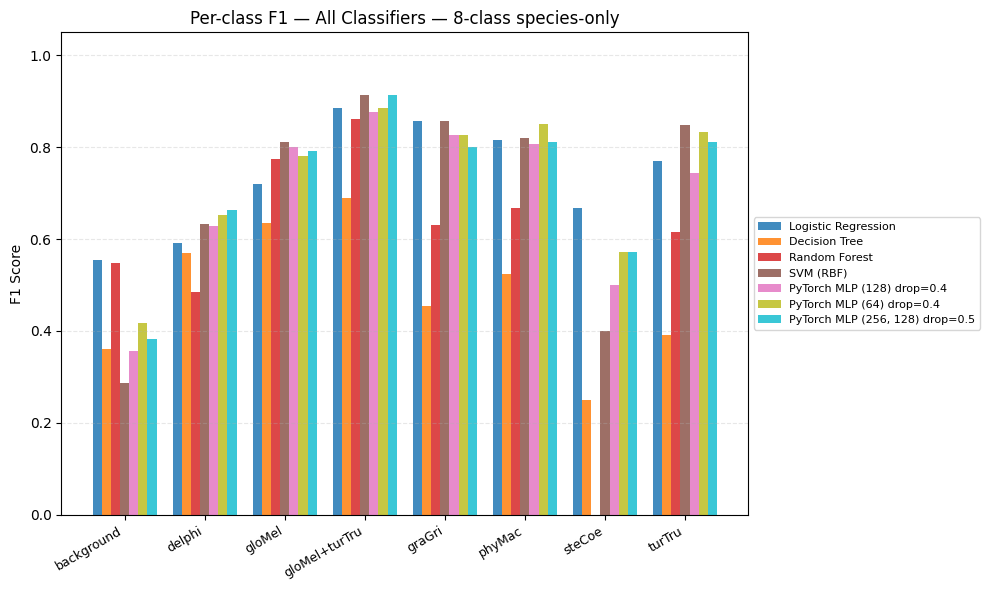

Saved to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/figures/f1_per_class_species_only.png


In [52]:
#@title Per-class F1 comparison bar chart

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score


def plot_per_class_f1(sk_results, mlp_results_dict, y_test_arr, class_names_arr,
                      variant_name, save_name):
    all_res = {**sk_results, **mlp_results_dict}
    n_clf = len(all_res)
    n_cls = len(class_names_arr)

    colors = plt.cm.tab10(np.linspace(0, 1, min(n_clf, 10)))
    x = np.arange(n_cls)
    width = 0.8 / n_clf

    fig, ax = plt.subplots(figsize=(max(10, 1.2 * n_cls), 6))

    for i, (name, res) in enumerate(all_res.items()):
        f1_per = f1_score(y_test_arr, res['y_pred'],
                          labels=list(range(n_cls)), average=None, zero_division=0)
        offset = (i - n_clf / 2 + 0.5) * width
        ax.bar(x + offset, f1_per, width, label=name,
               color=colors[i % len(colors)], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(class_names_arr, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Per-class F1 — All Classifiers — {variant_name}')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    out = f'{save_dir}/figures/{save_name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {out}')


if 'results' in dir() and 'mlp_results' in dir():
    plot_per_class_f1(
        results, mlp_results, y_test, class_names,
        variant_name=f'{len(class_names)}-class',
        save_name='f1_per_class_signal_species',
    )

if 'results_sp' in dir() and 'mlp_results_sp' in dir():
    plot_per_class_f1(
        results_sp, mlp_results_sp, y_test_sp, class_names_sp,
        variant_name=f'{len(class_names_sp)}-class species-only',
        save_name='f1_per_class_species_only',
    )

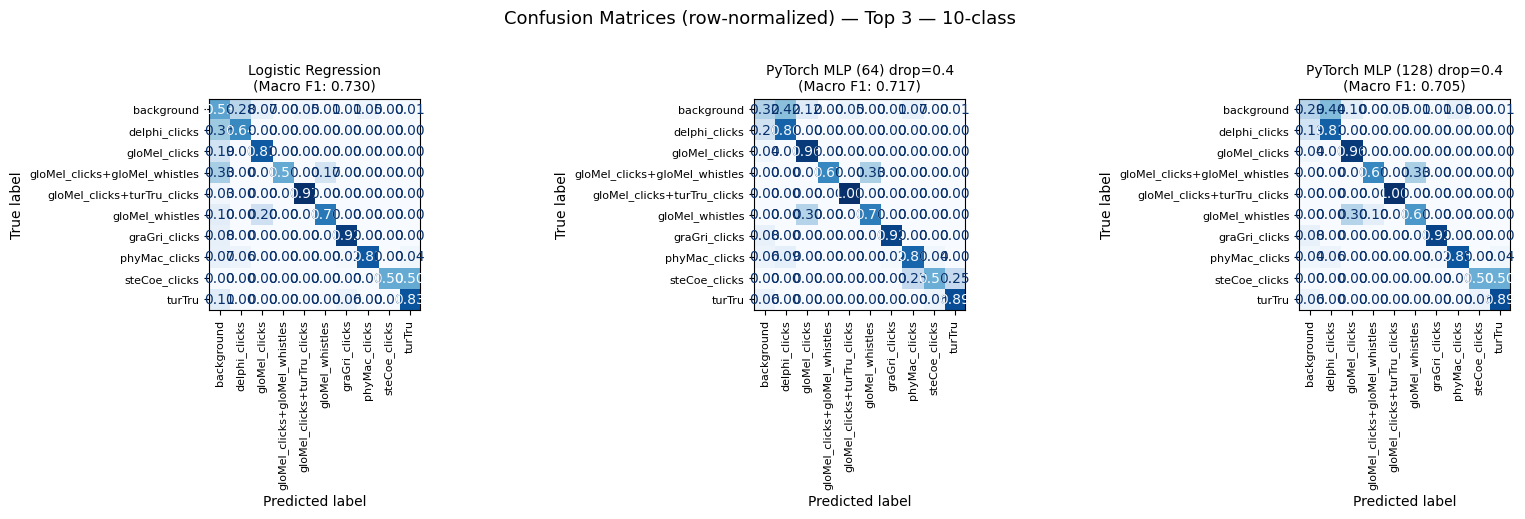

Saved to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/figures/confusion_top3_signal_species.png


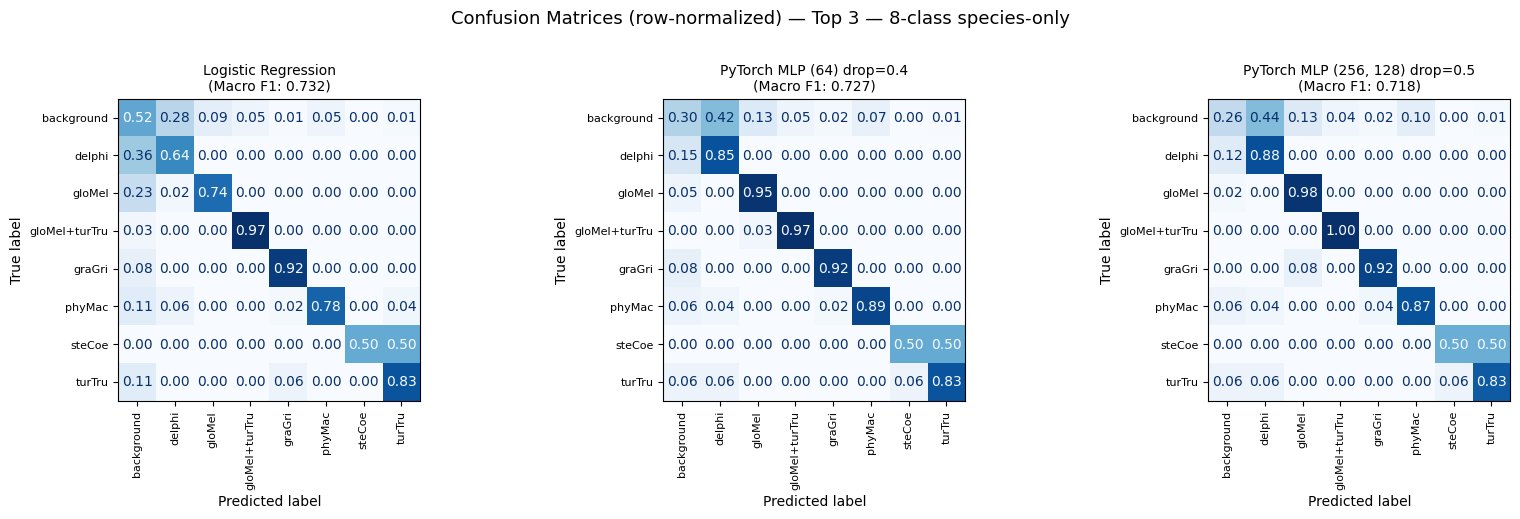

Saved to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/figures/confusion_top3_species_only.png


In [53]:
#@title Confusion matrices — Top N classifiers

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

TOP_N = 3


def plot_top_confusion(sk_results, mlp_results_dict, y_test_arr, class_names_arr,
                       variant_name, save_name, top_n=TOP_N):
    all_res = {**sk_results, **mlp_results_dict}
    top = sorted(all_res.items(), key=lambda x: x[1]['f1_macro'], reverse=True)[:top_n]

    fig, axes = plt.subplots(1, top_n, figsize=(5.5 * top_n, 5))
    if top_n == 1:
        axes = [axes]

    for ax, (name, res) in zip(axes, top):
        ConfusionMatrixDisplay.from_predictions(
            y_test_arr, res['y_pred'],
            display_labels=class_names_arr,
            ax=ax, colorbar=False,
            xticks_rotation='vertical', cmap='Blues',
            normalize='true',  # row-normalized; easier to read with imbalanced support
            values_format='.2f',
        )
        ax.set_title(f'{name}\n(Macro F1: {res["f1_macro"]:.3f})', fontsize=10)
        ax.tick_params(axis='both', labelsize=8)

    plt.suptitle(f'Confusion Matrices (row-normalized) — Top {top_n} — {variant_name}',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    out = f'{save_dir}/figures/{save_name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to {out}')


if 'results' in dir() and 'mlp_results' in dir():
    plot_top_confusion(
        results, mlp_results, y_test, class_names,
        variant_name=f'{len(class_names)}-class',
        save_name=f'confusion_top{TOP_N}_signal_species',
    )

if 'results_sp' in dir() and 'mlp_results_sp' in dir():
    plot_top_confusion(
        results_sp, mlp_results_sp, y_test_sp, class_names_sp,
        variant_name=f'{len(class_names_sp)}-class species-only',
        save_name=f'confusion_top{TOP_N}_species_only',
    )

In [ ]:
#@title Save full results to CSV — ALL classifiers, per variant

from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd


def save_results_csv(sk_results, mlp_results_dict, y_test_arr, class_names_arr,
                     variant_tag):
    all_res = {**sk_results, **mlp_results_dict}
    n_classes = len(class_names_arr)
    y_test_1h = label_binarize(y_test_arr, classes=list(range(n_classes)))

    rows = []
    for name, res in all_res.items():
        proba = res['y_proba']
        # OvR macro AUC over classes present in test
        try:
            present = np.where(y_test_1h.sum(axis=0) > 0)[0]
            auc = roc_auc_score(y_test_1h[:, present], proba[:, present],
                                average='macro', multi_class='ovr')
        except Exception:
            auc = None

        p, r, f, s = precision_recall_fscore_support(
            y_test_arr, res['y_pred'], labels=range(n_classes), zero_division=0,
        )

        row = {
            'classifier':    name,
            'variant':       variant_tag,
            'macro_f1':      res.get('f1_macro'),
            'weighted_f1':   res.get('f1_weighted'),
            'ovr_auc':       auc,
            'test_acc':      res.get('test_acc'),
            'train_acc':     res.get('train_acc'),
            'time_seconds':  res.get('time_s'),
        }
        for i, cls in enumerate(class_names_arr):
            row[f'{cls}_precision'] = round(p[i], 3)
            row[f'{cls}_recall']    = round(r[i], 3)
            row[f'{cls}_f1']        = round(f[i], 3)
            row[f'{cls}_support']   = int(s[i])
        rows.append(row)

    df = pd.DataFrame(rows)
    # Keep lead columns in a stable order
    lead = ['classifier', 'variant', 'macro_f1', 'weighted_f1', 'ovr_auc',
            'test_acc', 'train_acc', 'time_seconds']
    df = df[lead + [c for c in df.columns if c not in lead]]

    out_path = f'{save_dir}/perch_v2_results_{variant_tag}.csv'
    df.to_csv(out_path, index=False)
    print(f'Saved {len(df)} classifiers to {out_path}')
    display(df.round(3))
    return df


dfs = []
if 'results' in dir() and 'mlp_results' in dir():
    dfs.append(save_results_csv(
        results, mlp_results, y_test, class_names,
        variant_tag='signal_species',
    ))

if 'results_sp' in dir() and 'mlp_results_sp' in dir():
    dfs.append(save_results_csv(
        results_sp, mlp_results_sp, y_test_sp, class_names_sp,
        variant_tag='species_only',
    ))

# Combined CSV with both variants stacked (only for shared columns — per-class columns differ)
if len(dfs) == 2:
    shared_cols = ['classifier', 'variant', 'macro_f1', 'weighted_f1', 'ovr_auc',
                   'test_acc', 'train_acc', 'time_seconds']
    combined = pd.concat([d[shared_cols] for d in dfs], ignore_index=True)
    combined_path = f'{save_dir}/perch_v2_results_combined.csv'
    combined.to_csv(combined_path, index=False)
    print(f'\nCombined summary saved to {combined_path}')
    display(combined.round(3))

Saved 7 classifiers to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/perch_v2_results_signal_species.csv


,classifier,variant,macro_f1,weighted_f1,ovr_auc,test_acc,train_acc,time_seconds,background_precision,background_recall,...,phyMac_clicks_f1,phyMac_clicks_support,steCoe_clicks_precision,steCoe_clicks_recall,steCoe_clicks_f1,steCoe_clicks_support,turTru_precision,turTru_recall,turTru_f1,turTru_support
0,Logistic Regression,signal_species,0.730,0.670,0.951,0.674,1.000,3.268,0.623,0.529,...,0.838,54,1.000,0.50,0.667,4,0.714,0.833,0.769,18
1,Decision Tree,signal_species,0.419,0.477,0.706,0.488,0.811,1.490,0.474,0.301,...,0.593,54,0.100,0.25,0.143,4,0.348,0.444,0.390,18
2,Random Forest,signal_species,0.468,0.561,0.943,0.566,1.000,1.210,0.462,0.634,...,0.688,54,0.000,0.00,0.000,4,1.000,0.500,0.667,18
3,SVM (RBF),signal_species,0.665,0.557,0.947,0.613,0.715,4.186,0.591,0.170,...,0.807,54,1.000,0.25,0.400,4,0.938,0.833,0.882,18
4,PyTorch MLP (128) drop=0.4,signal_species,0.705,0.615,0.949,0.645,0.842,2.894,0.672,0.294,...,0.821,54,0.667,0.50,0.571,4,0.762,0.889,0.821,18
5,PyTorch MLP (64) drop=0.4,signal_species,0.717,0.624,0.950,0.647,0.825,3.930,0.671,0.320,...,0.789,54,0.400,0.50,0.444,4,0.889,0.889,0.889,18
6,"PyTorch MLP (256, 128) drop=0.5",signal_species,0.700,0.573,0.947,0.627,0.771,2.965,0.667,0.183,...,0.838,54,0.667,0.50,0.571,4,0.842,0.889,0.865,18


Saved 7 classifiers to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/perch_v2_results_species_only.csv


,classifier,variant,macro_f1,weighted_f1,ovr_auc,test_acc,train_acc,time_seconds,background_precision,background_recall,...,phyMac_f1,phyMac_support,steCoe_precision,steCoe_recall,steCoe_f1,steCoe_support,turTru_precision,turTru_recall,turTru_f1,turTru_support
0,Logistic Regression,species_only,0.732,0.661,0.940,0.664,1.000,1.016,0.598,0.516,...,0.816,54,1.000,0.50,0.667,4,0.714,0.833,0.769,18
1,Decision Tree,species_only,0.484,0.487,0.708,0.493,0.850,1.529,0.400,0.327,...,0.524,54,0.250,0.25,0.250,4,0.348,0.444,0.390,18
2,Random Forest,species_only,0.573,0.598,0.935,0.600,1.000,1.213,0.478,0.641,...,0.667,54,0.000,0.00,0.000,4,1.000,0.444,0.615,18
3,SVM (RBF),species_only,0.697,0.583,0.937,0.640,0.732,3.786,0.667,0.183,...,0.821,54,1.000,0.25,0.400,4,0.933,0.778,0.848,18
4,PyTorch MLP (128) drop=0.4,species_only,0.693,0.598,0.939,0.640,0.804,1.567,0.685,0.242,...,0.807,54,0.500,0.50,0.500,4,0.765,0.722,0.743,18
5,PyTorch MLP (64) drop=0.4,species_only,0.727,0.635,0.944,0.667,0.843,3.253,0.687,0.301,...,0.850,54,0.667,0.50,0.571,4,0.833,0.833,0.833,18
6,"PyTorch MLP (256, 128) drop=0.5",species_only,0.718,0.621,0.941,0.662,0.782,2.587,0.714,0.261,...,0.810,54,0.667,0.50,0.571,4,0.789,0.833,0.811,18



Combined summary saved to /data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES/perch_v2_results_combined.csv


,classifier,variant,macro_f1,weighted_f1,ovr_auc,test_acc,train_acc,time_seconds
0,Logistic Regression,signal_species,0.730,0.670,0.951,0.674,1.000,3.268
1,Decision Tree,signal_species,0.419,0.477,0.706,0.488,0.811,1.490
2,Random Forest,signal_species,0.468,0.561,0.943,0.566,1.000,1.210
3,SVM (RBF),signal_species,0.665,0.557,0.947,0.613,0.715,4.186
4,PyTorch MLP (128) drop=0.4,signal_species,0.705,0.615,0.949,0.645,0.842,2.894
5,PyTorch MLP (64) drop=0.4,signal_species,0.717,0.624,0.950,0.647,0.825,3.930
6,"PyTorch MLP (256, 128) drop=0.5",signal_species,0.700,0.573,0.947,0.627,0.771,2.965
7,Logistic Regression,species_only,0.732,0.661,0.940,0.664,1.000,1.016
8,Decision Tree,species_only,0.484,0.487,0.708,0.493,0.850,1.529
9,Random Forest,species_only,0.573,0.598,0.935,0.600,1.000,1.213


: 

Species view: 5202 points, classes:
background                                                     4348
delphi                                                          307
phyMac                                                          179
gloMel                                                          121
gloMel_clicks+turTru_clicks                                     106
turTru                                                           58
graGri                                                           45
gloMel_clicks+gloMel_whistles                                    20
steCoe                                                           15
gloMel_clicks+gloMel_whistles+turTru_clicks+turTru_whistles       3
Name: count, dtype: int64

Call-type view: 5202 points, classes:
background                                                     4348
clicks                                                          690
gloMel_clicks+turTru_clicks                                     106
whistles       

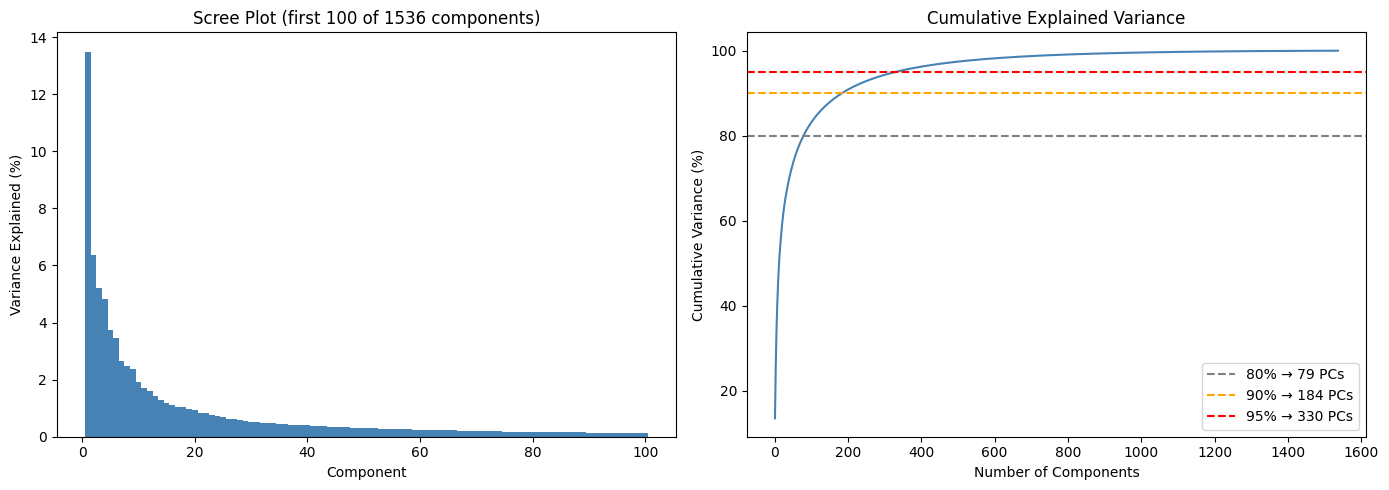

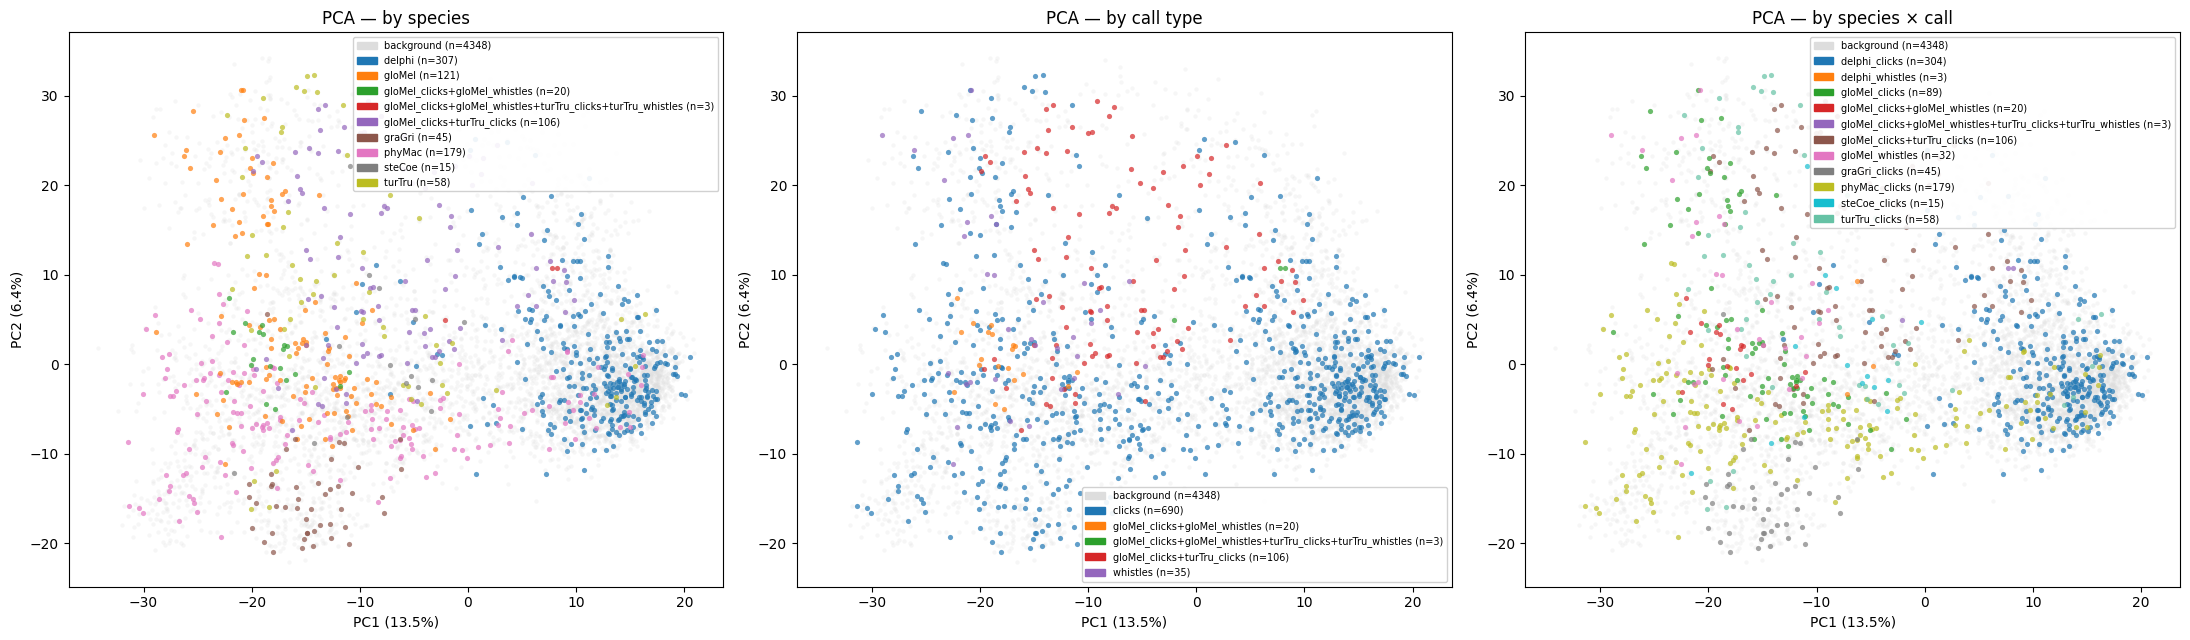

PCA-reduced shape for t-SNE/UMAP input: (5202, 184)

Running t-SNE...
  t-SNE metric: euclidean...
  t-SNE metric: cosine...
  t-SNE metric: manhattan...
  t-SNE metric: correlation...


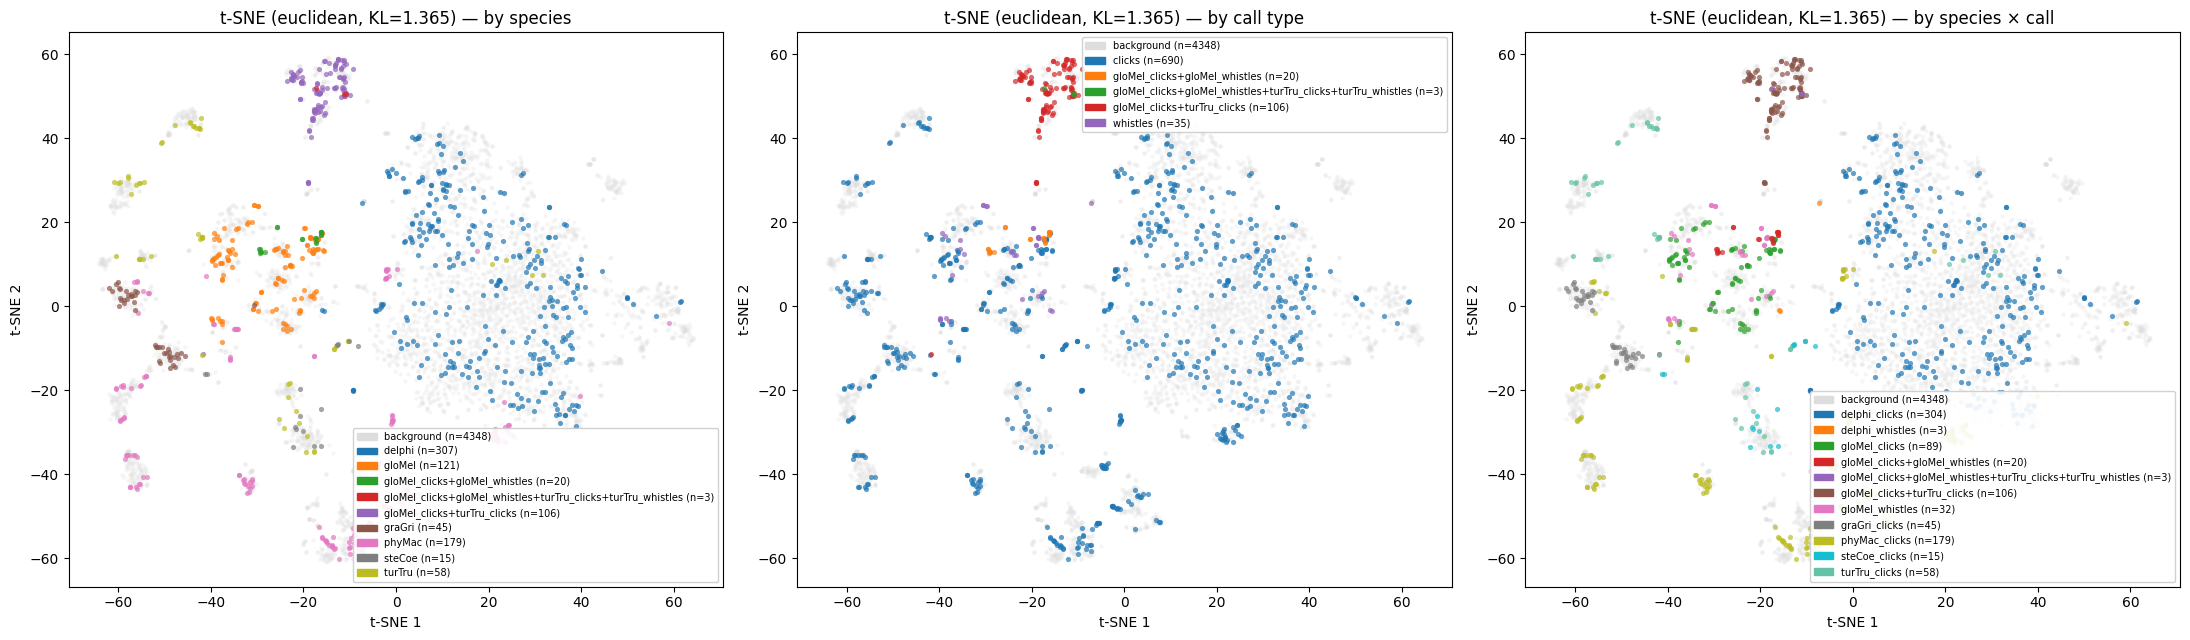

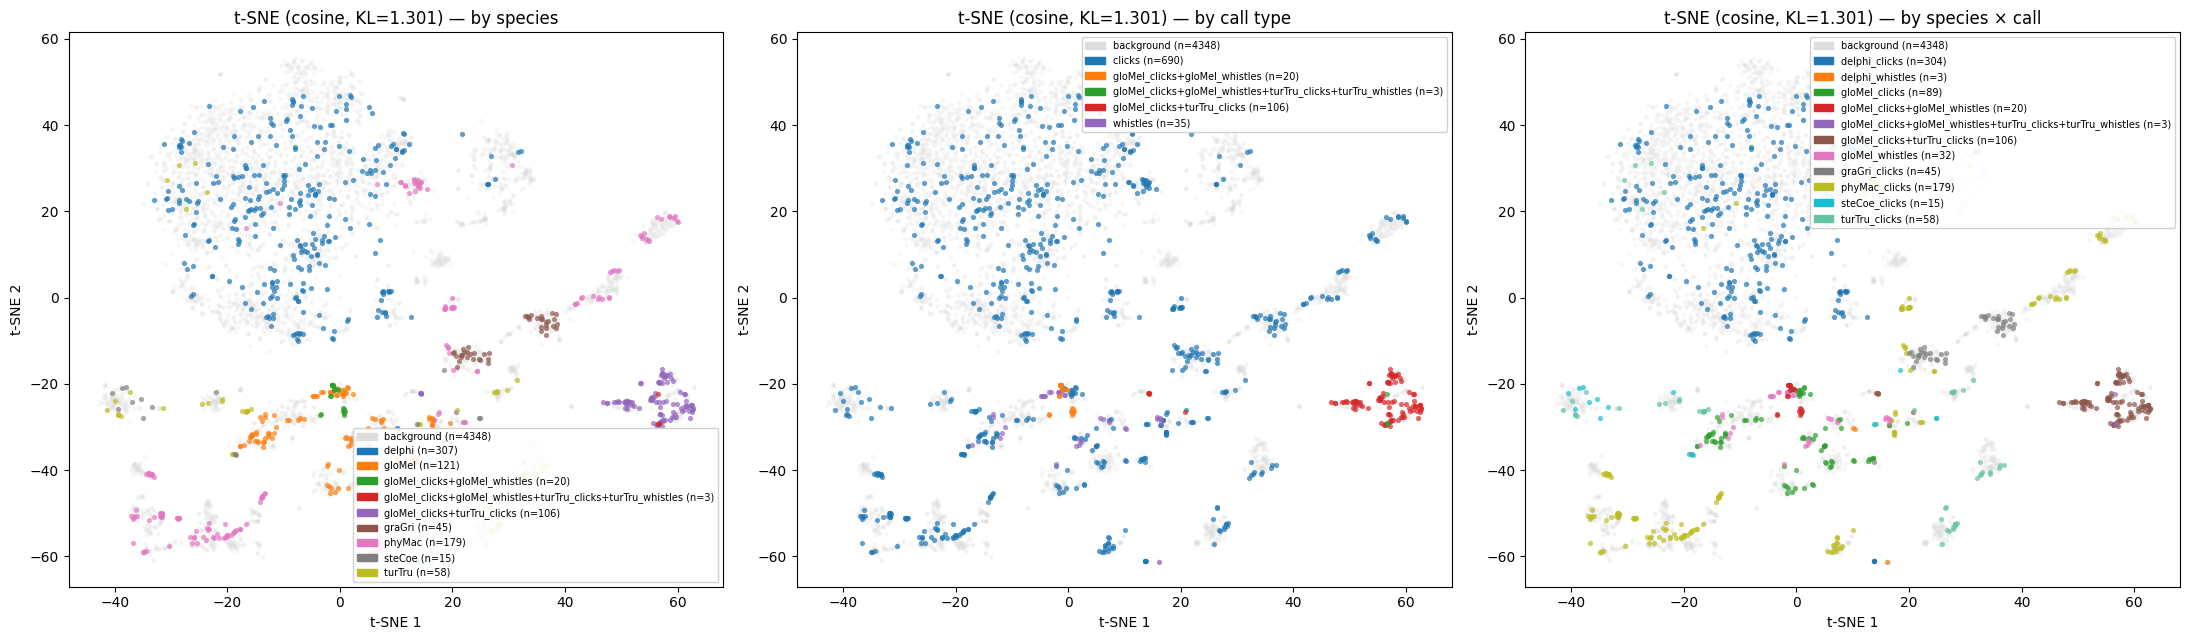

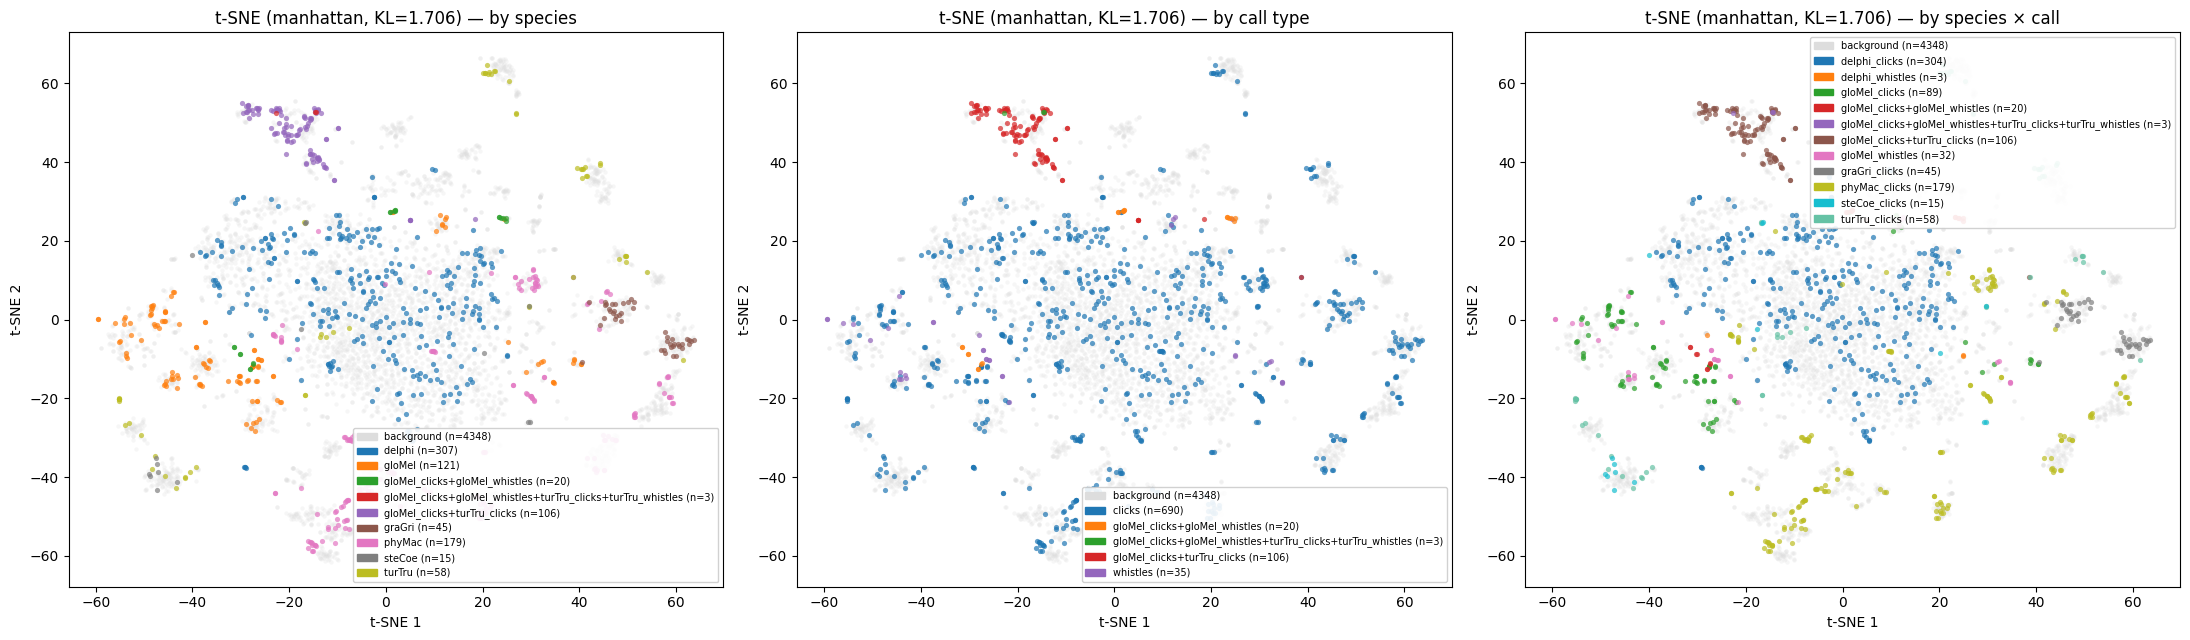

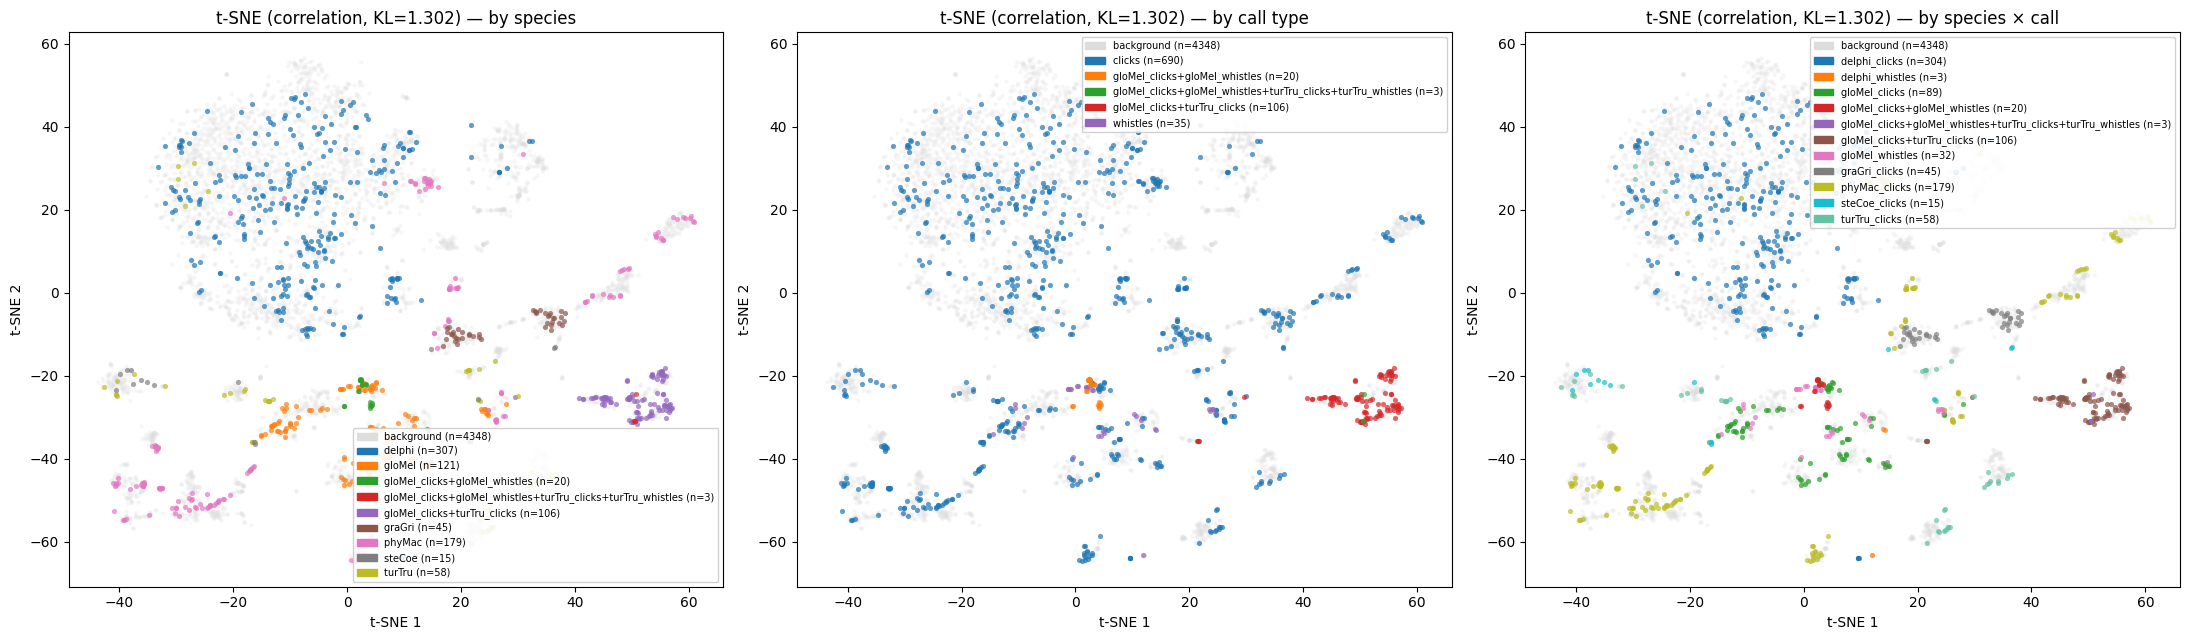

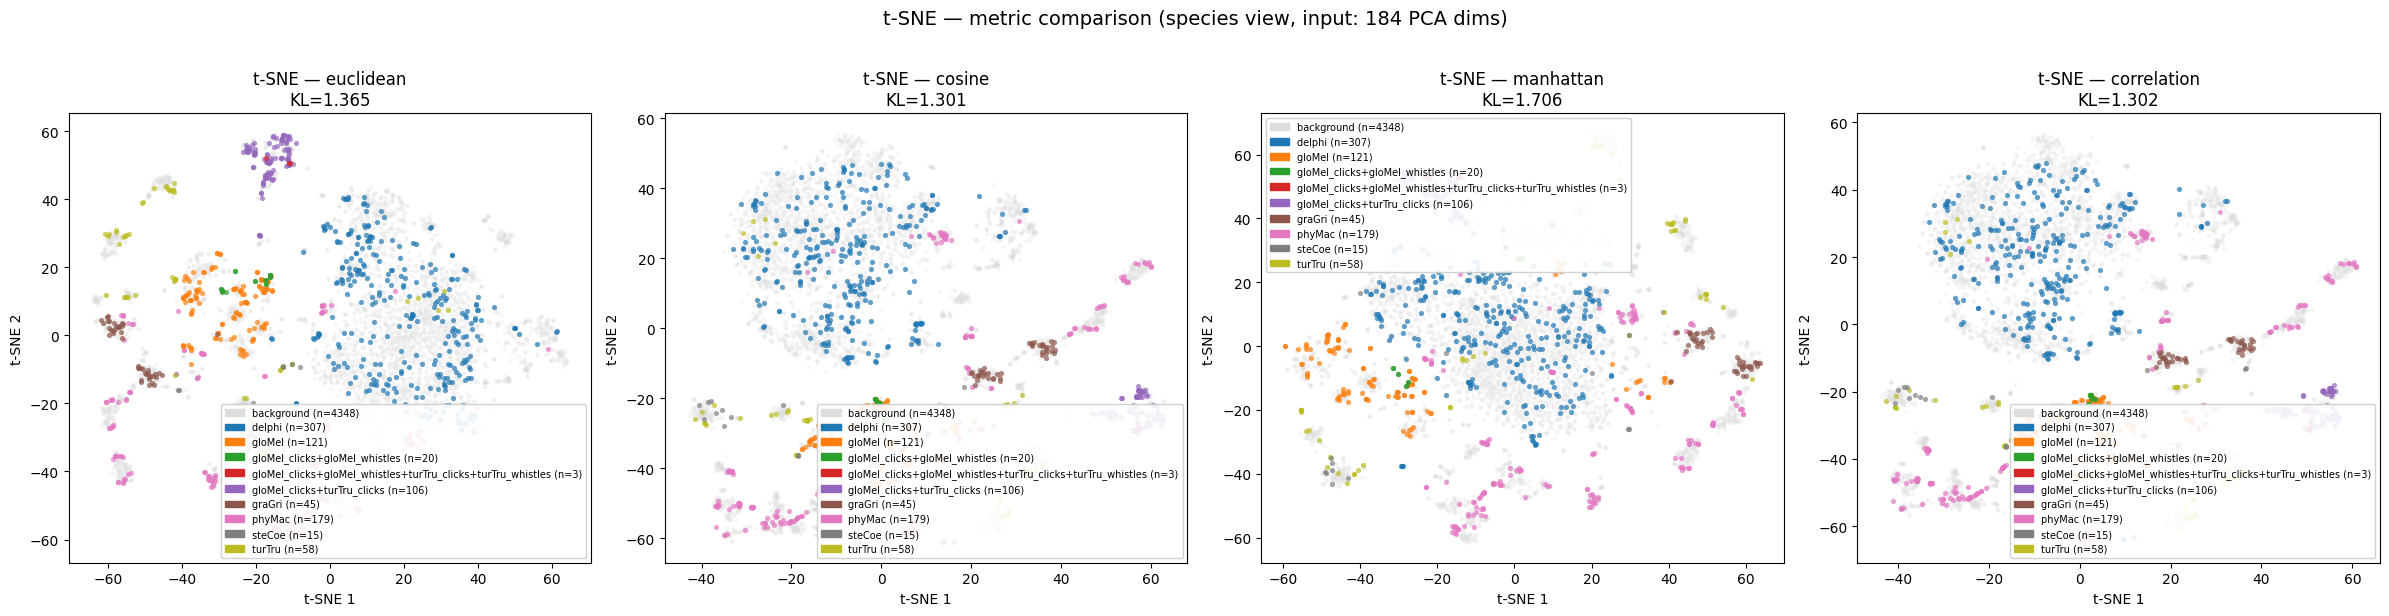


Running UMAP...
  UMAP metric: euclidean...
  UMAP metric: cosine...
  UMAP metric: manhattan...
  UMAP metric: correlation...


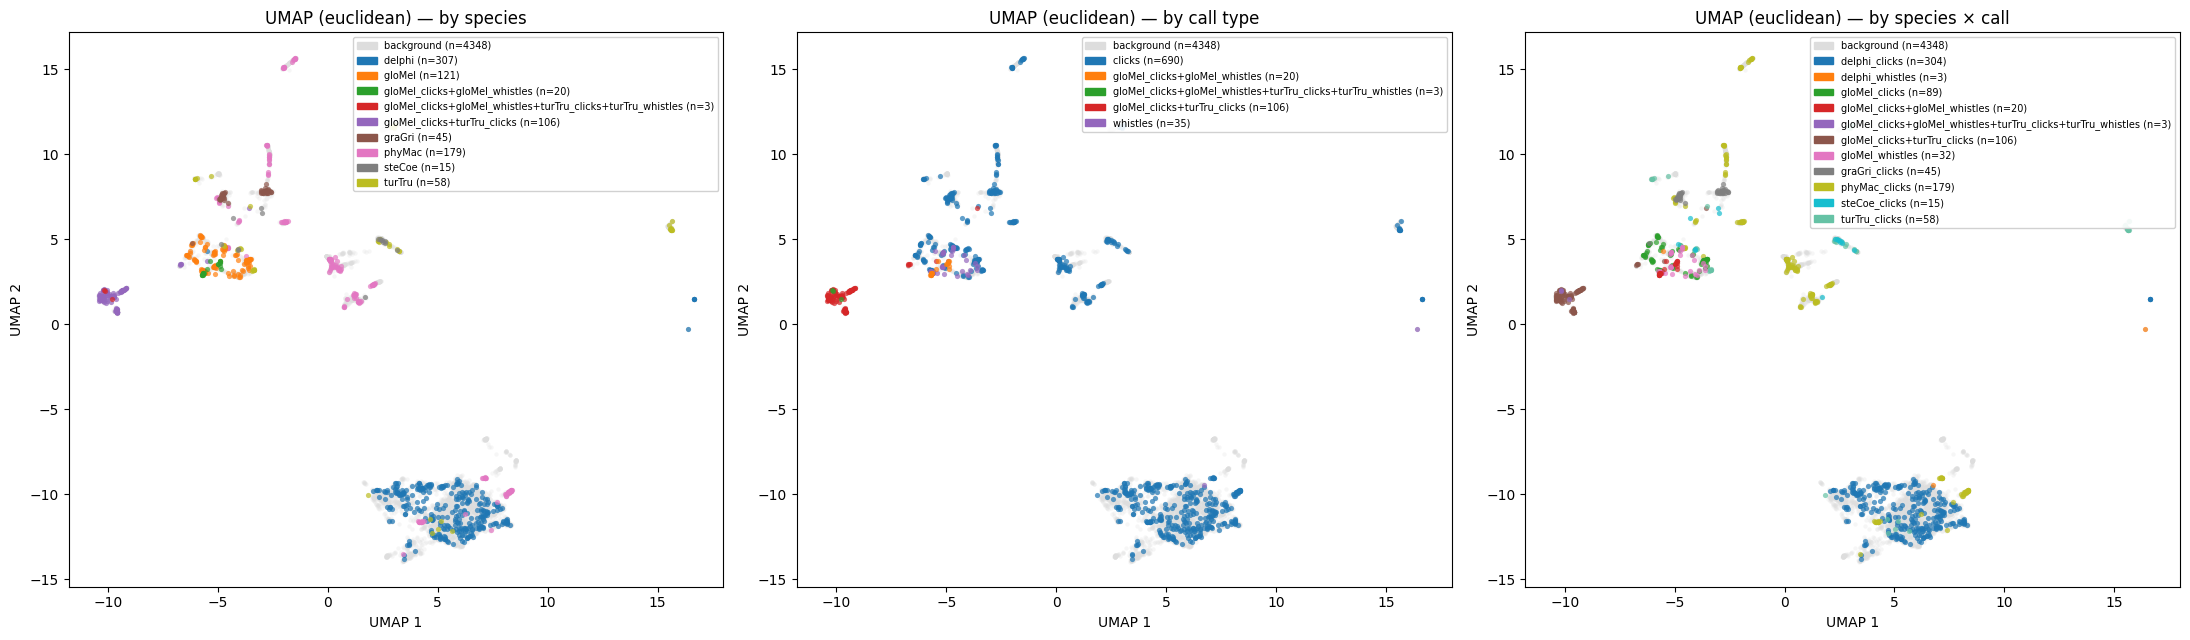

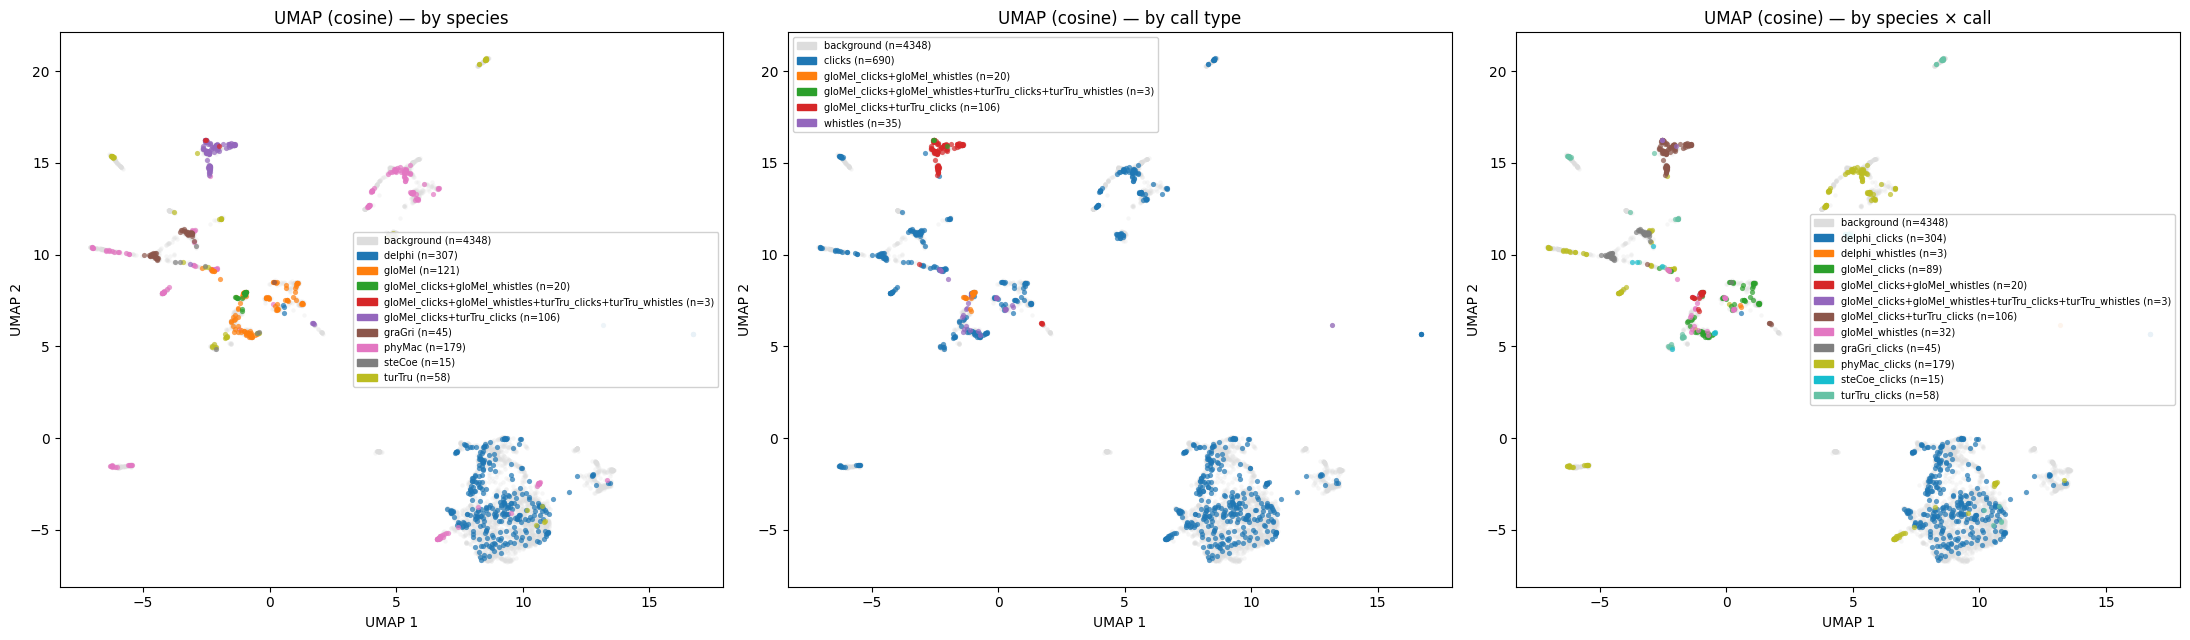

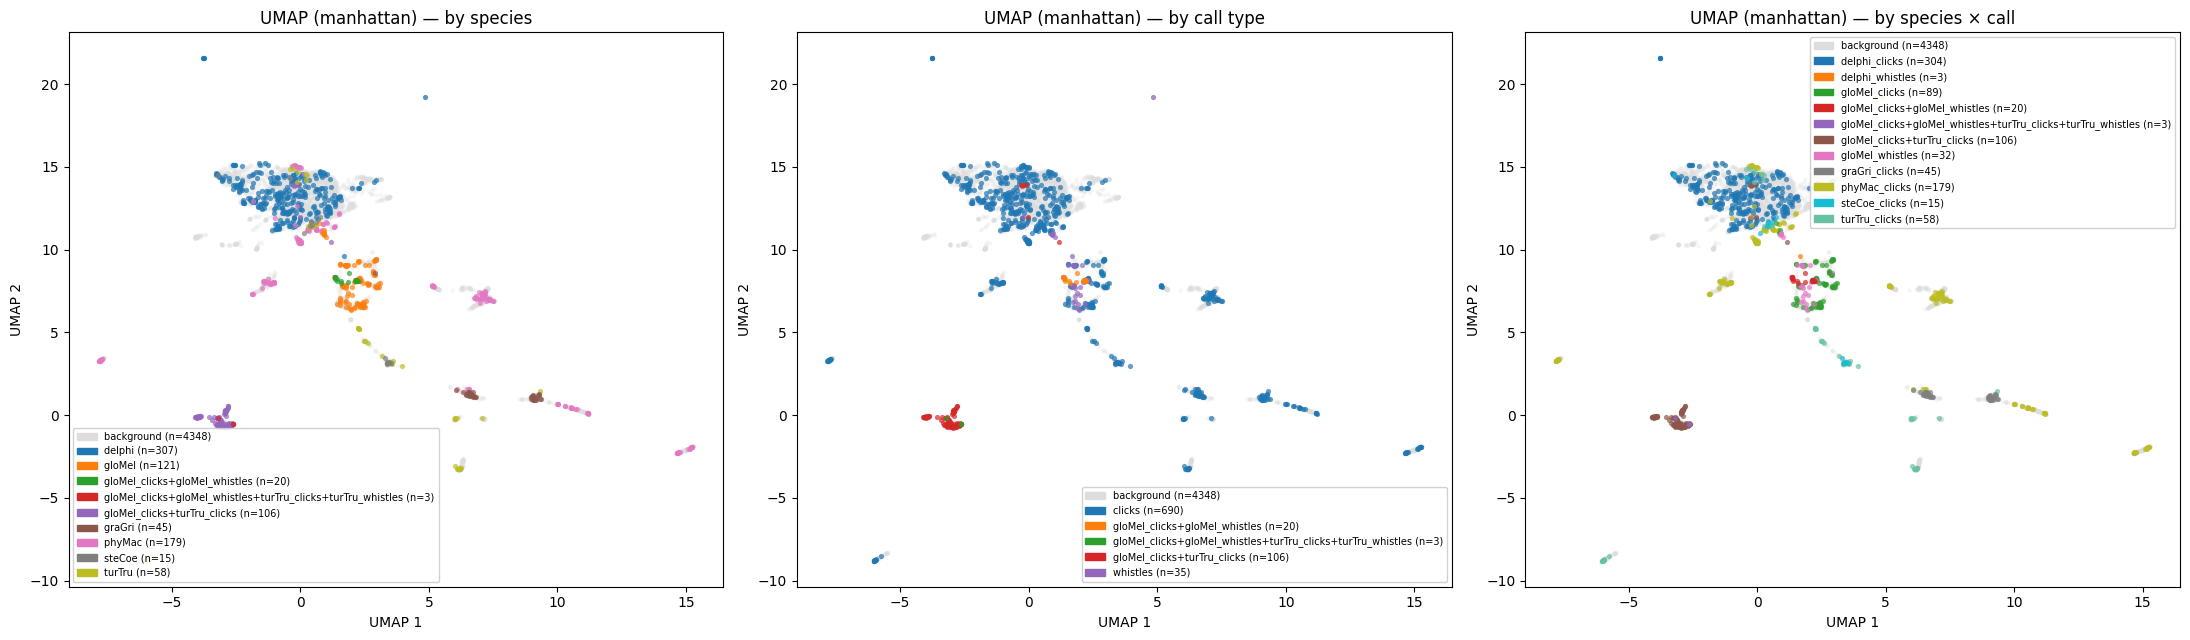

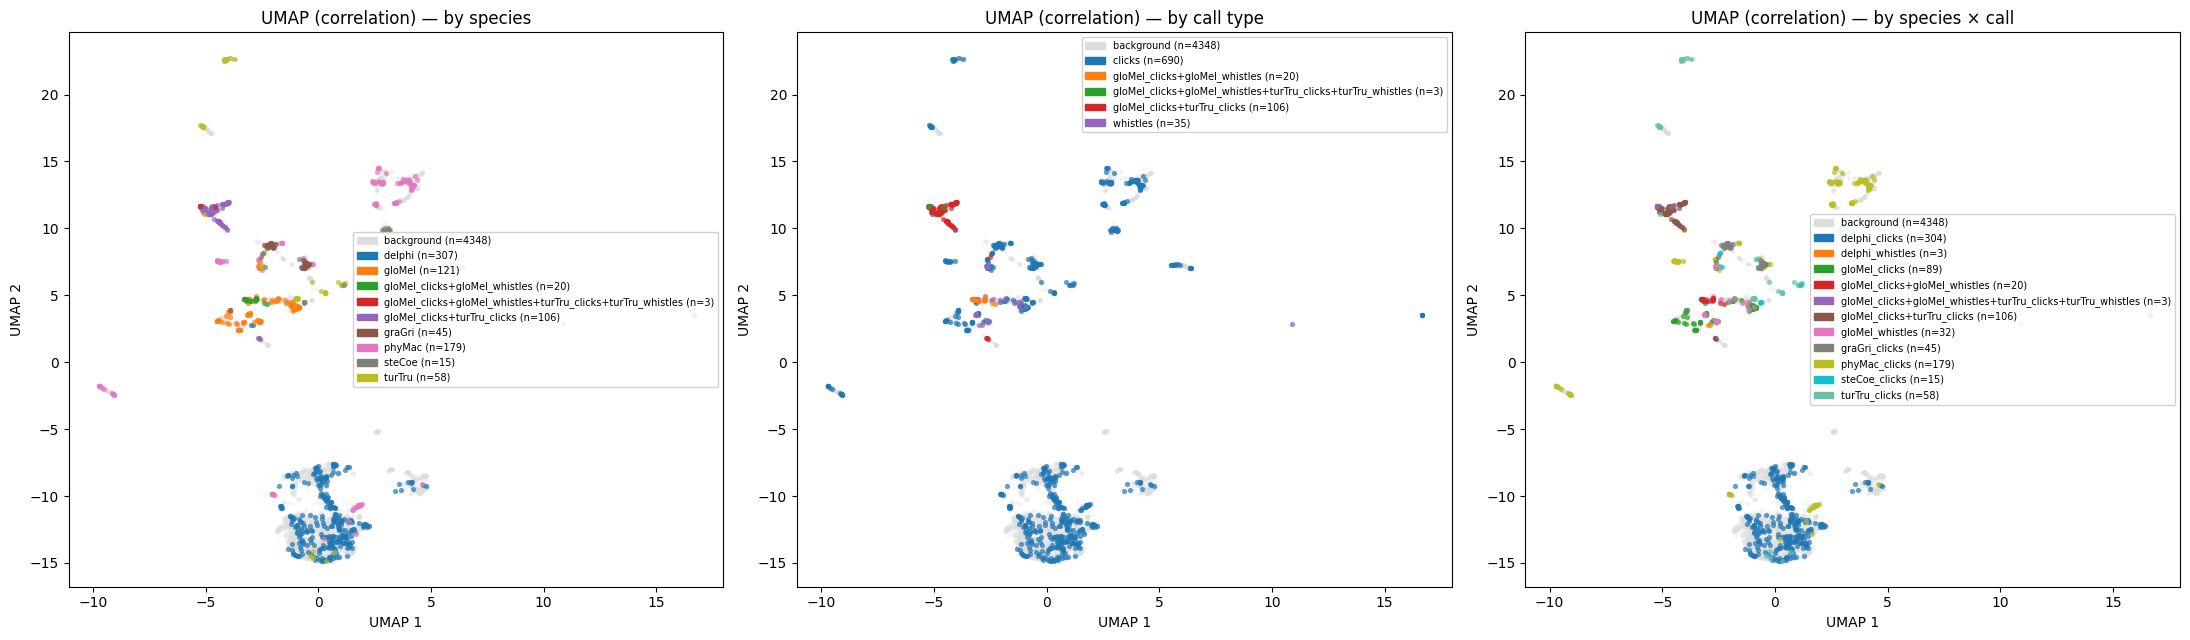

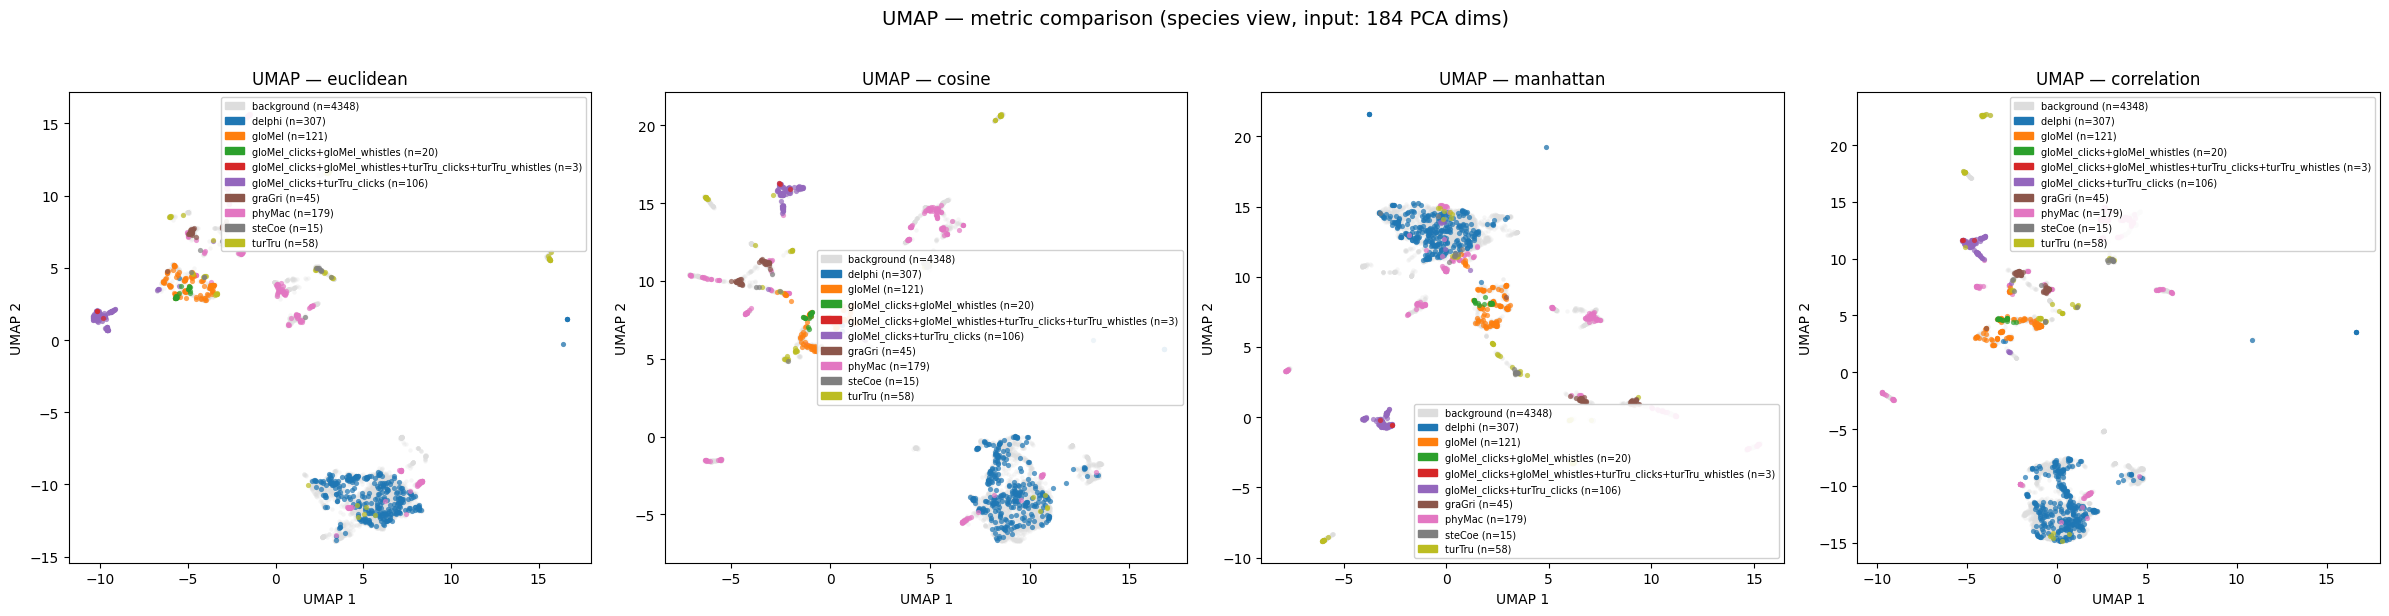


PCA input dims: 1536 → reduced to 184 (90% variance)

t-SNE KL Divergence by metric (lower = better fit):
  cosine           KL: 1.3009
  correlation      KL: 1.3022
  euclidean        KL: 1.3651
  manhattan        KL: 1.7062
All coordinates and label views saved.


In [10]:
#@title Dimensionality reduction — PCA + t-SNE & UMAP (Alnitak Cavanilles)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs(f'{save_dir}/dim_red', exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════════════
# 0. Build label views (species, call-type, species×call-type)
# ═══════════════════════════════════════════════════════════════════════════════
# Rule: mixed labels (containing '+') are kept as their own category in ALL
# views — the authors annotated them as such, so they represent a distinct
# acoustic situation (e.g. simultaneous vocalizations from multiple species).
# No splitting; one row → one label per view.

def parse_label(lbl):
    """Return (species, call_type) for a label string.
    Mixed labels (with '+') are kept whole as their own category in both views."""
    if lbl == 'background':
        return ('background', 'background')
    if '+' in lbl:
        # Keep mixed labels intact — they're a distinct annotated class.
        return (lbl, lbl)
    species, call = lbl.rsplit('_', 1)
    return (species, call)

lbl_species = np.empty(len(y_clean), dtype=object)
lbl_call    = np.empty(len(y_clean), dtype=object)

for i, lbl in enumerate(y_clean):
    sp, cl = parse_label(lbl)
    lbl_species[i] = sp
    lbl_call[i]    = cl

lbl_species = np.asarray(lbl_species)
lbl_call    = np.asarray(lbl_call)
lbl_raw     = y_clean.copy()

print(f'Species view: {len(lbl_species)} points, classes:')
print(pd.Series(lbl_species).value_counts())
print(f'\nCall-type view: {len(lbl_call)} points, classes:')
print(pd.Series(lbl_call).value_counts())
print(f'\nRaw view: {len(lbl_raw)} points, classes:')
print(pd.Series(lbl_raw).value_counts())

# ═══════════════════════════════════════════════════════════════════════════════
# 0b. Palettes — background always light gray, others qualitative
# ═══════════════════════════════════════════════════════════════════════════════
def make_palette(classes, bg_key='background'):
    """Light gray for background, tab10/Set2 for the rest."""
    others = [c for c in classes if c != bg_key]
    base = list(plt.cm.tab10.colors) + list(plt.cm.Set2.colors) + list(plt.cm.Set3.colors)
    palette = {bg_key: '#DDDDDD'} if bg_key in classes else {}
    for i, cls in enumerate(others):
        palette[cls] = base[i % len(base)]
    return palette

species_classes = sorted(set(lbl_species))
call_classes    = sorted(set(lbl_call))
raw_classes     = sorted(set(lbl_raw))

species_palette = make_palette(species_classes)
call_palette    = make_palette(call_classes)
raw_palette     = make_palette(raw_classes)

# ═══════════════════════════════════════════════════════════════════════════════
# 0c. Generic plotter — recolor any 2D coords by any label vector
# ═══════════════════════════════════════════════════════════════════════════════
def plot_embedding(ax, coords, labels, palette, title,
                   bg_key='background', s=10, alpha_bg=0.25, alpha_fg=0.7,
                   s_fg=14):
    """Plot background first (faded), then foreground classes on top."""
    labels = np.asarray(labels)
    # background underneath
    if bg_key in palette:
        m = labels == bg_key
        ax.scatter(coords[m, 0], coords[m, 1],
                   c=palette[bg_key], alpha=alpha_bg, s=s, linewidths=0)
    # foreground on top, smallest classes drawn last so they're visible
    fg_classes = [c for c in palette if c != bg_key]
    counts = {c: int((labels == c).sum()) for c in fg_classes}
    for cls in sorted(fg_classes, key=lambda c: -counts[c]):  # large first, small last
        m = labels == cls
        if m.sum() == 0:
            continue
        ax.scatter(coords[m, 0], coords[m, 1],
                   c=[palette[cls]], alpha=alpha_fg, s=s_fg, linewidths=0)
    ax.set_title(title)
    legend_patches = [mpatches.Patch(color=palette[c], label=f'{c} (n={int((labels==c).sum())})')
                      for c in palette]
    ax.legend(handles=legend_patches, fontsize=7, loc='best', framealpha=0.9)

# Convenience: produce all 3 views for a given coordinate set
def plot_all_views(coords_full, base_title, savepath_prefix,
                   xlabel='Dim 1', ylabel='Dim 2'):
    fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))
    plot_embedding(axes[0], coords_full, lbl_species,
                   species_palette, f'{base_title} — by species')
    plot_embedding(axes[1], coords_full, lbl_call,
                   call_palette, f'{base_title} — by call type')
    plot_embedding(axes[2], coords_full, lbl_raw,
                   raw_palette, f'{base_title} — by species × call')
    for ax in axes:
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(savepath_prefix + '.png', dpi=150, bbox_inches='tight')
    plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 1. Standardize + Full PCA (variance analysis)
# ═══════════════════════════════════════════════════════════════════════════════
scaler_viz = StandardScaler()
X_scaled = scaler_viz.fit_transform(X_clean)

print('Running full PCA...')
pca_full = PCA(random_state=random_seed)
pca_full.fit(X_scaled)

n_total = len(pca_full.explained_variance_ratio_)
cumvar_full = np.cumsum(pca_full.explained_variance_ratio_) * 100

var_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(n_total)],
    'Variance Explained (%)': pca_full.explained_variance_ratio_ * 100,
    'Cumulative (%)': cumvar_full
})
print(f'Total components: {n_total}')
print(var_df.head(30).to_string(index=False, float_format='%.4f'))

n80 = np.argmax(cumvar_full >= 80) + 1
n90 = np.argmax(cumvar_full >= 90) + 1
n95 = np.argmax(cumvar_full >= 95) + 1
n99 = np.argmax(cumvar_full >= 99) + 1
print(f'\nComponents for 80% variance: {n80}')
print(f'Components for 90% variance: {n90}')
print(f'Components for 95% variance: {n95}')
print(f'Components for 99% variance: {n99}')

n_pca = n90
print(f'→ Using {n_pca} PCA components for t-SNE/UMAP input (90% variance)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
n_show = min(100, n_total)
ax1.bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100,
        color='steelblue', width=1.0)
ax1.set_xlabel('Component'); ax1.set_ylabel('Variance Explained (%)')
ax1.set_title(f'Scree Plot (first {n_show} of {n_total} components)')

ax2.plot(range(1, n_total + 1), cumvar_full, color='steelblue')
ax2.axhline(80, color='gray',   linestyle='--', label=f'80% → {n80} PCs')
ax2.axhline(90, color='orange', linestyle='--', label=f'90% → {n90} PCs')
ax2.axhline(95, color='red',    linestyle='--', label=f'95% → {n95} PCs')
ax2.set_xlabel('Number of Components'); ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance'); ax2.legend()
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_full_variance.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. PCA 2D — three views
# ═══════════════════════════════════════════════════════════════════════════════
pca2   = PCA(n_components=2, random_state=random_seed)
X_pca2 = pca2.fit_transform(X_scaled)

xlabel = f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)'
ylabel = f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)'
plot_all_views(X_pca2, 'PCA', f'{save_dir}/dim_red/pca_2d_views',
               xlabel=xlabel, ylabel=ylabel)

# ═══════════════════════════════════════════════════════════════════════════════
# 3. PCA-reduce for t-SNE / UMAP input
# ═══════════════════════════════════════════════════════════════════════════════
pca_red   = PCA(n_components=n_pca, random_state=random_seed)
X_pca_red = pca_red.fit_transform(X_scaled)
print(f'PCA-reduced shape for t-SNE/UMAP input: {X_pca_red.shape}')

# ═══════════════════════════════════════════════════════════════════════════════
# 4. t-SNE — multiple metrics, then 3 views per metric
# ═══════════════════════════════════════════════════════════════════════════════
metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']

print('\nRunning t-SNE...')
tsne_results = {}
for metric in metrics:
    print(f'  t-SNE metric: {metric}...')
    tsne = TSNE(
        n_components=2, perplexity=40, learning_rate='auto',
        init='random' if metric != 'euclidean' else 'pca',
        max_iter=1000, metric=metric,
        random_state=random_seed, verbose=0
    )
    X_tsne = tsne.fit_transform(X_pca_red)
    tsne_results[metric] = {'coords': X_tsne, 'kl': tsne.kl_divergence_}

# One figure per metric showing all 3 views
for metric, data in tsne_results.items():
    plot_all_views(data['coords'],
                   f't-SNE ({metric}, KL={data["kl"]:.3f})',
                   f'{save_dir}/dim_red/tsne_{metric}_views',
                   xlabel='t-SNE 1', ylabel='t-SNE 2')

# Compact metric-comparison figure (species view only, for quick scan)
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, metric in zip(axes, metrics):
    plot_embedding(ax, tsne_results[metric]['coords'], lbl_species,
                   species_palette,
                   f't-SNE — {metric}\nKL={tsne_results[metric]["kl"]:.3f}')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.suptitle(f't-SNE — metric comparison (species view, input: {n_pca} PCA dims)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/tsne_metrics_species.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. UMAP — multiple metrics, then 3 views per metric
# ═══════════════════════════════════════════════════════════════════════════════
print('\nRunning UMAP...')
try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    import umap

umap_results = {}
for metric in metrics:
    print(f'  UMAP metric: {metric}...')
    reducer = umap.UMAP(
        n_neighbors=30, min_dist=0.1, n_components=2,
        metric=metric, random_state=random_seed, verbose=False
    )
    umap_results[metric] = reducer.fit_transform(X_pca_red)

for metric, coords in umap_results.items():
    plot_all_views(coords,
                   f'UMAP ({metric})',
                   f'{save_dir}/dim_red/umap_{metric}_views',
                   xlabel='UMAP 1', ylabel='UMAP 2')

# Compact metric-comparison figure (species view)
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, metric in zip(axes, metrics):
    plot_embedding(ax, umap_results[metric], lbl_species,
                   species_palette, f'UMAP — {metric}')
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
plt.suptitle(f'UMAP — metric comparison (species view, input: {n_pca} PCA dims)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/umap_metrics_species.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 6. Summary + save coords & label views
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print(f'PCA input dims: {X_scaled.shape[1]} → reduced to {n_pca} (90% variance)')
print(f'\nt-SNE KL Divergence by metric (lower = better fit):')
for metric, data in sorted(tsne_results.items(), key=lambda x: x[1]['kl']):
    print(f'  {metric:15s}  KL: {data["kl"]:.4f}')

np.save(f'{save_dir}/dim_red/coords_pca2.npy', X_pca2)
for metric in metrics:
    np.save(f'{save_dir}/dim_red/coords_tsne_{metric}.npy', tsne_results[metric]['coords'])
    np.save(f'{save_dir}/dim_red/coords_umap_{metric}.npy', umap_results[metric])

# Save the label views so re-coloring later doesn't require re-parsing
np.save(f'{save_dir}/dim_red/lbl_species.npy', lbl_species)
np.save(f'{save_dir}/dim_red/lbl_call.npy',    lbl_call)
np.save(f'{save_dir}/dim_red/lbl_raw.npy',     lbl_raw)
print('All coordinates and label views saved.')

In [12]:
#@title Quantitative quality metrics — Alnitak Cavanilles (3 label views)
from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness
from sklearn.preprocessing import LabelEncoder

# Encode each label view
le_species = LabelEncoder(); y_species = le_species.fit_transform(lbl_species)
le_call    = LabelEncoder(); y_call    = le_call.fit_transform(lbl_call)
le_raw     = LabelEncoder(); y_raw     = le_raw.fit_transform(lbl_raw)

label_views = [
    ('species', y_species),
    ('call',    y_call),
    ('raw',     y_raw),
]

print('\n' + '=' * 95)
print('QUANTITATIVE QUALITY METRICS — Alnitak Cavanilles')
print('=' * 95)
print(f'{"Method":<10} {"Metric":<13} {"Trust":>8}  '
      f'{"Sil(species)":>13} {"Sil(call)":>10} {"Sil(raw)":>10}')
print('-' * 95)

def sil_row(coords):
    return [silhouette_score(coords, y) for _, y in label_views]

for metric, data in tsne_results.items():
    trust = trustworthiness(X_pca_red, data['coords'], n_neighbors=15)
    sils  = sil_row(data['coords'])
    print(f'{"t-SNE":<10} {metric:<13} {trust:>8.4f}  '
          f'{sils[0]:>13.4f} {sils[1]:>10.4f} {sils[2]:>10.4f}')

print()
for metric, coords in umap_results.items():
    trust = trustworthiness(X_pca_red, coords, n_neighbors=15)
    sils  = sil_row(coords)
    print(f'{"UMAP":<10} {metric:<13} {trust:>8.4f}  '
          f'{sils[0]:>13.4f} {sils[1]:>10.4f} {sils[2]:>10.4f}')

print()
trust_pca = trustworthiness(X_pca_red, X_pca2, n_neighbors=15)
sils_pca  = sil_row(X_pca2)
print(f'{"PCA (2D)":<10} {"euclidean":<13} {trust_pca:>8.4f}  '
      f'{sils_pca[0]:>13.4f} {sils_pca[1]:>10.4f} {sils_pca[2]:>10.4f}')


QUANTITATIVE QUALITY METRICS — Alnitak Cavanilles
Method     Metric           Trust   Sil(species)  Sil(call)   Sil(raw)
-----------------------------------------------------------------------------------------------
t-SNE      euclidean       0.9725        -0.4207    -0.2144    -0.4315
t-SNE      cosine          0.9735        -0.4304    -0.2535    -0.4434
t-SNE      manhattan       0.9585        -0.3386    -0.1867    -0.3676
t-SNE      correlation     0.9737        -0.4214    -0.2427    -0.4343

UMAP       euclidean       0.9541        -0.5972    -0.2022    -0.6049
UMAP       cosine          0.9586        -0.5705    -0.2354    -0.5767
UMAP       manhattan       0.9380        -0.5371    -0.2698    -0.5442
UMAP       correlation     0.9584        -0.5825    -0.2434    -0.5890

PCA (2D)   euclidean       0.7607        -0.4632    -0.3169    -0.4823


the negative silhouette values determine us to look at per-class silhouette score for signals

In [ ]:
#@title Per-class silhouette — diagnostic by label view
from sklearn.metrics import silhouette_samples
import pandas as pd
import numpy as np

def per_class_silhouette(coords, labels, exclude=('background',)):
    """Return DataFrame: class -> {n, mean_silhouette}.
    Also returns the mean across non-excluded classes (macro avg)."""
    labels = np.asarray(labels)
    sil_samples = silhouette_samples(coords, labels)
    rows = []
    for cls in sorted(set(labels)):
        m = labels == cls
        rows.append({
            'class':      cls,
            'n':          int(m.sum()),
            'silhouette': float(sil_samples[m].mean()),
        })
    df = pd.DataFrame(rows).sort_values('silhouette', ascending=False)
    macro = df[~df['class'].isin(exclude)]['silhouette'].mean()
    return df, macro

def report_view(view_name, labels, results_dict, key='coords'):
    print('\n' + '=' * 90)
    print(f'PER-CLASS SILHOUETTE — view: {view_name}')
    print('=' * 90)

    summary_rows = []
    detail_tables = {}

    for method_name, payload in results_dict.items():
        coords = payload[key] if isinstance(payload, dict) else payload
        df, macro = per_class_silhouette(coords, labels)
        detail_tables[method_name] = df
        summary_rows.append({'method': method_name,
                             'macro_sil_excl_bg': macro})

    summary = pd.DataFrame(summary_rows).sort_values(
        'macro_sil_excl_bg', ascending=False)
    print('\nMacro-average silhouette (background excluded), ranked:')
    print(summary.to_string(index=False, float_format='%.4f'))

    # Show per-class breakdown for the best method
    best_method = summary.iloc[0]['method']
    print(f'\nPer-class breakdown for best method: {best_method}')
    print(detail_tables[best_method].to_string(index=False, float_format='%.4f'))
    return summary, detail_tables

# Build a unified results dict so each method shows up once per (algo, metric)
all_results = {}
for metric, data in tsne_results.items():
    all_results[f't-SNE/{metric}'] = data            # has 'coords'
for metric, coords in umap_results.items():
    all_results[f'UMAP/{metric}']  = {'coords': coords}
all_results['PCA/euclidean']       = {'coords': X_pca2}

# Run for each label view
species_summary, species_detail = report_view('species',  lbl_species, all_results)
call_summary,    call_detail    = report_view('call',     lbl_call,    all_results)
raw_summary,     raw_detail     = report_view('raw',      lbl_raw,     all_results)

# ───────────────────────────────────────────────────────────────────────────────
# Cross-view comparison: macro silhouette (bg excluded) per method per view
# ───────────────────────────────────────────────────────────────────────────────
print('\n' + '=' * 90)
print('CROSS-VIEW COMPARISON — macro silhouette (background excluded)')
print('=' * 90)
combined = (species_summary.rename(columns={'macro_sil_excl_bg': 'species'})
            .merge(call_summary.rename(columns={'macro_sil_excl_bg': 'call'}),  on='method')
            .merge(raw_summary.rename(columns={'macro_sil_excl_bg': 'raw'}),    on='method'))
combined = combined.sort_values('species', ascending=False)
print(combined.to_string(index=False, float_format='%.4f'))

# Save
os.makedirs(f'{save_dir}/dim_red/silhouette', exist_ok=True)
combined.to_csv(f'{save_dir}/dim_red/silhouette/macro_summary.csv', index=False)
for view_name, detail in [('species', species_detail),
                          ('call',    call_detail),
                          ('raw',     raw_detail)]:
    for method, df in detail.items():
        safe = method.replace('/', '_')
        df.to_csv(f'{save_dir}/dim_red/silhouette/{view_name}__{safe}.csv', index=False)
print('\nPer-class silhouette tables saved to dim_red/silhouette/')


PER-CLASS SILHOUETTE — view: species

Macro-average silhouette (background excluded), ranked:
           method  macro_sil_excl_bg
  t-SNE/euclidean             0.1145
      UMAP/cosine             0.0944
 UMAP/correlation             0.0895
   UMAP/euclidean             0.0845
     t-SNE/cosine             0.0690
t-SNE/correlation             0.0619
  t-SNE/manhattan             0.0450
   UMAP/manhattan             0.0374
    PCA/euclidean             0.0244

Per-class breakdown for best method: t-SNE/euclidean
                                                      class    n  silhouette
                                                     graGri   45      0.6408
                              gloMel_clicks+gloMel_whistles   20      0.4560
gloMel_clicks+gloMel_whistles+turTru_clicks+turTru_whistles    3      0.3965
                                                     steCoe   15      0.3780
                                                     delphi  307      0.2111
                   

: 

In [1]:
# ── Reload coords + refined labels (with background subtypes) ─────────────────
import numpy as np
import pandas as pd

metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']
save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/ALNITAK_CAVANILLES'

X_pca2 = np.load(f'{save_dir}/dim_red/coords_pca2.npy')
tsne   = {m: np.load(f'{save_dir}/dim_red/coords_tsne_{m}.npy') for m in metrics}
umap   = {m: np.load(f'{save_dir}/dim_red/coords_umap_{m}.npy') for m in metrics}

# y_labels.npy already contains the refined background sublabels
# (background_FAD_deep, background_boat_deep, etc.) — use this, not lbl_raw
y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy', allow_pickle=True)

print(f'PCA 2D:   {X_pca2.shape}')
print(f'Labels:   {len(y_clean)} points, {len(set(y_clean))} classes')
print()
print(pd.Series(y_clean).value_counts().to_string())

PCA 2D:   (5202, 2)
Labels:   5202 points, 17 classes

background_FAD_deep                                            2594
background_boat_deep                                            978
background_sailing_shallow                                      440
delphi_clicks                                                   304
background_sailing_deep                                         233
phyMac_clicks                                                   179
gloMel_clicks+turTru_clicks                                     106
gloMel_clicks                                                    89
background_boat_shallow                                          85
turTru_clicks                                                    58
graGri_clicks                                                    45
gloMel_whistles                                                  32
gloMel_clicks+gloMel_whistles                                    20
background_fishing_gear                                      

In [3]:
# ── Background subtypes — PCA + t-SNE/UMAP grids, thesis plotly style ─────────
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

GREY, FONT = "#5a5a5a", "Helvetica Neue, Arial, sans-serif"

# Fixed colour map — reuse this EXACT dict everywhere
BG_COLORS = {
    'background_FAD_deep'       : '#2f9292',   # teal
    'background_boat_deep'      : '#EF9F27',   # amber
    'background_boat_shallow'   : '#7b5bc9',   # violet
    'background_sailing_deep'   : '#D85A30',   # coral
    'background_sailing_shallow': '#0c6dcf',   # deep blue
    'background_fishing_gear'   : '#888780',   # neutral grey
}
NON_BG_COLOR = "#9aa0a6"   # faded context

# If running in a fresh kernel, uncomment to load from disk:
# metrics  = ['euclidean', 'cosine', 'manhattan', 'correlation']
# X_pca2   = np.load(f"{save_dir}/dim_red/coords_pca2.npy")
# y_clean  = np.load(f"{save_dir}/embeddings/y_labels.npy")
# tsne     = {m: np.load(f"{save_dir}/dim_red/coords_tsne_{m}.npy") for m in metrics}
# umap     = {m: np.load(f"{save_dir}/dim_red/coords_umap_{m}.npy") for m in metrics}

def _clean(cls):
    return cls.replace('background_', '').replace('_', ' ')

def add_bg_traces(fig, coords, labels, row=None, col=None, show_legend=False):
    """Faded non-background underneath, coloured background subtypes on top."""
    labels = np.asarray(labels)
    mask_non = np.array([l not in BG_COLORS for l in labels])
    fig.add_trace(go.Scatter(
        x=coords[mask_non, 0], y=coords[mask_non, 1], mode='markers',
        name='non-background', legendgroup='non-background', showlegend=show_legend,
        marker=dict(size=5, color=NON_BG_COLOR, opacity=0.40, line=dict(width=0)),
        hoverinfo='skip',
    ), row=row, col=col)
    for cls, hexcol in BG_COLORS.items():
        mask = labels == cls
        if mask.sum() == 0:
            continue
        fig.add_trace(go.Scatter(
            x=coords[mask, 0], y=coords[mask, 1], mode='markers',
            name=_clean(cls), legendgroup=cls, showlegend=show_legend,
            marker=dict(size=6, color=hexcol, opacity=0.82,
                        line=dict(width=0.4, color='white')),
        ), row=row, col=col)

def _style(fig, title, width, height):
    fig.update_layout(
        template="plotly_white", width=width, height=height,
        paper_bgcolor="white", plot_bgcolor="white",
        font=dict(family=FONT, size=12, color=GREY),
        margin=dict(l=70, r=180, t=60, b=60),
        legend=dict(title=dict(text="class", font=dict(size=12, color=GREY)),
                    x=1.02, xanchor="left", y=0.5, yanchor="middle",
                    itemsizing="constant", font=dict(size=11, color=GREY),
                    bgcolor="rgba(0,0,0,0)"),
    )
    fig.update_xaxes(showgrid=True, gridcolor="#e3e3e3", gridwidth=0.5,
                     zeroline=False, linecolor="#e3e3e3")
    fig.update_yaxes(showgrid=True, gridcolor="#e3e3e3", gridwidth=0.5,
                     zeroline=False, linecolor="#e3e3e3")
# ── PCA ──────────────────────────────────────────────────────────────────────
var0, var1 = 19.79, 5.65   # PC1 / PC2, from full PCA (same X_scaled)
fig = go.Figure()
add_bg_traces(fig, X_pca2, y_clean, show_legend=True)
_style(fig, "PCA (EMBEDDINGS) — background subtypes", 820, 560)
fig.update_xaxes(title=dict(text=f"Component 1 ({var0:.1f}%)", font=dict(size=12, color=GREY)))
fig.update_yaxes(title=dict(text=f"Component 2 ({var1:.1f}%)", font=dict(size=12, color=GREY)))
fig.show()
# fig.write_image(f"{save_dir}/dim_red/bg_pca_plotly.png", scale=3)

# ── t-SNE grid (1×4) ─────────────────────────────────────────────────────────
fig = make_subplots(rows=1, cols=4, subplot_titles=[f"t-SNE — {m}" for m in metrics],
                    horizontal_spacing=0.035)
for i, m in enumerate(metrics):
    add_bg_traces(fig, tsne[m], y_clean, row=1, col=i+1, show_legend=(i == 0))
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)
_style(fig, "t-SNE (EMBEDDINGS) — background subtypes", 1500, 430)
for ann in fig.layout.annotations:          # restyle subplot titles
    ann.font = dict(size=11, color=GREY, family=FONT)
fig.show()
# fig.write_image(f"{save_dir}/dim_red/bg_tsne_plotly.png", scale=3)

# ── UMAP grid (1×4) ──────────────────────────────────────────────────────────
fig = make_subplots(rows=1, cols=4, subplot_titles=[f"UMAP — {m}" for m in metrics],
                    horizontal_spacing=0.035)
for i, m in enumerate(metrics):
    add_bg_traces(fig, umap[m], y_clean, row=1, col=i+1, show_legend=(i == 0))
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)
_style(fig, "UMAP (EMBEDDINGS) — background subtypes", 1500, 430)
for ann in fig.layout.annotations:
    ann.font = dict(size=11, color=GREY, family=FONT)
fig.show()
# fig.write_image(f"{save_dir}/dim_red/bg_umap_plotly.png", scale=3)

In [5]:
# ── Reload t-SNE coords + KL divergences ─────────────────────────────────────
import numpy as np

metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']

# KL values aren't saved — hardcode from the original run output
# (check your printed output from the dim-reduction cell and paste here)
kl_values = {
    'euclidean'  : 0.0,   # ← replace with your actual values
    'cosine'     : 0.0,
    'manhattan'  : 0.0,
    'correlation': 0.0,
}

tsne_results = {
    m: {
        'coords': np.load(f'{save_dir}/dim_red/coords_tsne_{m}.npy'),
        'kl'    : kl_values[m],
    }
    for m in metrics
}

y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy', allow_pickle=True)

print('Loaded t-SNE coords:')
for m, d in tsne_results.items():
    print(f'  {m:15s}  shape={d["coords"].shape}  KL={d["kl"]}')
    
    # ── Reload label views ────────────────────────────────────────────────────────
lbl_species = np.load(f'{save_dir}/dim_red/lbl_species.npy', allow_pickle=True)
lbl_call    = np.load(f'{save_dir}/dim_red/lbl_call.npy',    allow_pickle=True)
lbl_raw     = np.load(f'{save_dir}/dim_red/lbl_raw.npy',     allow_pickle=True)


Loaded t-SNE coords:
  euclidean        shape=(5202, 2)  KL=0.0
  cosine           shape=(5202, 2)  KL=0.0
  manhattan        shape=(5202, 2)  KL=0.0
  correlation      shape=(5202, 2)  KL=0.0


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CET-DET dim-red figure style — PLOTLY (thesis look)
# Drop-in: same names/signatures as the matplotlib version.
# Needs plotly >= 5.15 (multiple legends). Static export needs kaleido.
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

GREY, FONT = "#5a5a5a", "Helvetica Neue, Arial, sans-serif"

# ── Palettes (identical to the matplotlib module) ─────────────────────────────
SPECIES_COLORS = {
    'background':'#D8D7D0','delphi':'#2f9292','phyMac':'#EF9F27','gloMel':'#7b5bc9',
    'turTru':'#D85A30','graGri':'#0c6dcf','steCoe':'#888780',
}
CALL_COLORS = {'background':'#D8D7D0','clicks':'#2f9292','whistles':'#EF9F27'}
BG_COLORS = {
    'background_FAD_deep':'#2f9292','background_boat_deep':'#EF9F27',
    'background_boat_shallow':'#7b5bc9','background_sailing_deep':'#D85A30',
    'background_sailing_shallow':'#0c6dcf','background_fishing_gear':'#888780',
}
_BASE_COLS = ['#2f9292','#EF9F27','#7b5bc9','#D85A30','#0c6dcf','#888780',
              '#1D9E75','#c45bcb','#e06b1a','#3a7abf','#6dab6d','#c94040']

def make_raw_palette(labels):
    palette = {'background':'#D8D7D0'}
    fg = [c for c in sorted(set(labels)) if c != 'background']
    for i, cls in enumerate(fg):
        palette[cls] = _BASE_COLS[i % len(_BASE_COLS)]
    return palette

def _clean(c):
    return c.replace('background_', '').replace('_', ' ')

# ── Add one labeling view to a subplot row, bound to its own legend ───────────
def _add_view(fig, coords, labels, palette, row, legend_id,
              bg_key='background', bg_alpha=0.30, s_bg=4, s_fg=7):
    labels = np.asarray(labels)
    # background first → bottom, faded
    if bg_key in palette and (labels == bg_key).sum() > 0:
        m = labels == bg_key
        fig.add_trace(go.Scatter(
            x=coords[m,0], y=coords[m,1], mode='markers',
            name=f'{_clean(bg_key)} (n={int(m.sum())})', legend=legend_id,
            marker=dict(size=s_bg, color=palette[bg_key], opacity=bg_alpha,
                        line=dict(width=0)), hoverinfo='skip',
        ), row=row, col=1)
    # foreground: largest first (bottom), rarest on top
    fg = [c for c in palette if c != bg_key]
    counts = {c:int((labels==c).sum()) for c in fg}
    for cls in sorted(fg, key=lambda c: -counts.get(c,0)):
        if counts.get(cls,0) == 0:
            continue
        m = labels == cls
        fig.add_trace(go.Scatter(
            x=coords[m,0], y=coords[m,1], mode='markers',
            name=f'{_clean(cls)} (n={counts[cls]})', legend=legend_id,
            marker=dict(size=s_fg, color=palette[cls], opacity=0.88,
                        line=dict(width=0.4, color='white')),
        ), row=row, col=1)

# ── Main: 3 stacked views, thesis plotly style ────────────────────────────────
def cet_dimred_3views(coords, lbl_species, lbl_call, lbl_raw,
                      method='t-SNE', metric='cosine', kl=None,
                      savepath=None, width=820, height=1550):
    raw_palette = make_raw_palette(lbl_raw)
    sub = f'{method} {metric}' + (f'  (KL={kl:.3f})' if kl else '')
    d1, d2 = f'{method} 1', f'{method} 2'

    titles = [f'{sub} — by species', f'{sub} — by call type', f'{sub} — species × call']
    fig = make_subplots(rows=3, cols=1, vertical_spacing=0.07, subplot_titles=titles)

    _add_view(fig, coords, lbl_species, SPECIES_COLORS, 1, 'legend')
    _add_view(fig, coords, lbl_call,    CALL_COLORS,    2, 'legend2')
    _add_view(fig, coords, lbl_raw,     raw_palette,    3, 'legend3')

    for i in range(1, 4):
        fig.update_xaxes(title=dict(text=d1, font=dict(size=11, color=GREY)),
                         showticklabels=False, showgrid=True, gridcolor="#e3e3e3",
                         gridwidth=0.5, zeroline=False, linecolor="#e3e3e3",
                         row=i, col=1)
        fig.update_yaxes(title=dict(text=d2, font=dict(size=11, color=GREY)),
                         showticklabels=False, showgrid=True, gridcolor="#e3e3e3",
                         gridwidth=0.5, zeroline=False, linecolor="#e3e3e3",
                         row=i, col=1)
    # centre each legend on its row's vertical domain
    doms = [fig.layout.yaxis.domain, fig.layout.yaxis2.domain, fig.layout.yaxis3.domain]
    cy = [sum(d)/2 for d in doms]
    base = dict(xanchor='left', yanchor='middle', x=1.02, itemsizing='constant',
                font=dict(size=10, color=GREY), bgcolor='rgba(0,0,0,0)')

    fig.update_layout(
        template='plotly_white', width=width, height=height,
        paper_bgcolor='white', plot_bgcolor='white',
        font=dict(family=FONT, size=12, color=GREY),
        margin=dict(l=70, r=210, t=60, b=50),
        legend =dict(**base, y=cy[0], title=dict(text='species',        font=dict(size=11, color=GREY))),
        legend2=dict(**base, y=cy[1], title=dict(text='call type',      font=dict(size=11, color=GREY))),
        legend3=dict(**base, y=cy[2], title=dict(text='species × call', font=dict(size=11, color=GREY))),
    )
    for ann in fig.layout.annotations:        # restyle the subplot titles
        ann.font = dict(size=12, color=GREY, family=FONT)

    fig.show()
    return fig

In [8]:
cet_dimred_3views(
    coords      = tsne_results['cosine']['coords'],
    lbl_species = lbl_species,
    lbl_call    = lbl_call,
    lbl_raw     = lbl_raw,
    method      = 't-SNE',
    metric      = 'cosine',
    kl          = tsne_results['cosine']['kl'],
    savepath    = f'{save_dir}/dim_red/tsne_cosine_3views_plotly.png',
)